# ***Automatic Neuron Tracking System for Unconstrained Nematodes (ANTSUN) v2.2.0***

This pipeline takes as input `.nd2` files from the confocal scope corresponding to freely-moving and immobilized recordings for NeuroPAL, together with an `.h5` file from the NIR tracking camera. It processes the confocal data to locate and track neurons in the worm's head, and thereby generates GCaMP traces for these neurons. It also generates the NeuroPAL RGB image used for labeling, labels it with AutoCellLabeler, and maps the labels back to the freely-moving traces. It also processes the NIR data to extract behavioral variables that can be correlated with the calcium traces.

The expected runtime of this pipeline is 34 hours.


## General notes

### GPU acceleration

Many steps of `ANTSUN` are GPU-accelerated (they are labeled as such beforehand). Thus, you need to ensure that there is sufficient GPU memory on your device before running those steps. It is recommended to have at least 8GB available before running any GPU-accelerated step. You can view how much GPU memory is available by running `nvidia-smi`.

- On `flv-c1`, there is only one GPU with 8GB memory. ANTSUN will likely fail as this is not enough memory.
- On `flv-c2`, there are four GPUs, two with 16GB memory each and two with 24GB each.
- On `flv-c3`, there are four GPUs, three with 24GB memory each and one with 48GB.
- On `flv-c4`, there are four GPUs, each with 48GB.

If you're using a server with more than one GPU, you can specify which one to use (according to its index in `nvidia-smi` by setting `nvidia_smi_device` and `flv_c` appropriately). Please reserve the GPU using our [GPU reservations sheet](https://docs.google.com/spreadsheets/d/1wMQ_bGJly15_1CXspK0fWzs-bd-lF-tVMpOVZZZ6SAc/edit?gid=922051617#gid=922051617).

**Please restart the kernel after the notebook is done running.**

### Error recovery

If a step of the pipeline encounters an unexpected error, it is usually advisable to restart the kernel. **WARNING:** Restarting the kernel while save operations are in progress could corrupt the data files and possibly mean you would have to start over from the very beginning. Thus, before restarting the kernel, you should check that `JLD2` files are not actively being saved, and only restart the kernel once the pipeline is on a step other than saving them.

After you restart the kernel, rerun the "Load packages", "Data parameters" and "Initialize data dictionaries" steps of the pipeline. This should reset the pipeline into its last usable state. If the error was due to running out of memory or some other hardware issue, assuming there are computing resources available, you should then be able to run the pipeline from the step that generated the error through the end.

If the error was due to you making a mistake in the "Data parameters" section of the pipeline, you may need to rerun the "Pipeline parameters" and "Save parameter settings" sections of the notebook after running the "Initialize data dictionaries" step, but note that you should **not** rerun the "Read meta-parameters from the ND2 file" step.

In [1]:
nvidia_smi_device = 2
flv_c = 3

3

In [2]:
if flv_c == 1
    gpu_device = 0
elseif flv_c == 2
    if nvidia_smi_device < 2
        gpu_device = nvidia_smi_device + 2
    else
        gpu_device = nvidia_smi_device - 2
    end
elseif flv_c == 3
    if nvidia_smi_device < 2
        gpu_device = 1 - nvidia_smi_device
    else
        gpu_device = nvidia_smi_device
    end
else
    error("Unsupported flv-c version")
end 
gpu_device

2

In [3]:
ENV["CUDA_VISIBLE_DEVICES"] = "$(gpu_device)"

"2"

## Load packages

In [4]:
# Flavell lab packages
using ND2Process
using GPUFilter
using WormFeatureDetector
using NRRDIO
using FlavellBase
using SegmentationTools
using ImageDataIO
using RegistrationGraph
using ExtractRegisteredData
using CaAnalysis
using BehaviorDataNIR
using UNet2D
using ImageRegistration

# Other packages
using ProgressMeter
using PyCall
using PyPlot
using Statistics
using StatsBase
using DelimitedFiles
using Images
using Cairo
using Distributions
using DataStructures
using HDF5
using Interact
using WebIO
using Plots
# using GraphPlot
# using LightGraphs
# using SimpleWeightedGraphs
using Dates
using JLD2
using TotalVariation
using VideoIO
using Distributions
using MultivariateStats
using FFTW
using LinearAlgebra
using GLMNet
using InformationMeasures
using CUDA
using LsqFit
using Optim
using Rotations
using CoordinateTransformations
using ImageTransformations
using Interpolations
using H5Zblosc

using Distributed

┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
│ Please consider using an official build from https://julialang.org/downloads/.
└ @ CUDA ~/.julia/packages/CUDA/75aiI/src/initialization.jl:180


WebIO._IJuliaInit()

2025-01-16 22:52:28.760311: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-16 22:52:28.760383: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-16 22:52:28.777432: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-16 22:52:28.817440: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-01-16 22:52:29.570836: W tensorflow/compiler/tf2

# Parameter settings

Expected runtime: 1 minute

### Data parameters

This section includes dataset-specific parameters, including the filename, voxel spacing, laser intensity step-up, and channel identities. It must be run every time you initialize the pipeline. 

**Important:** If you already have dictionaries saved and are rerunning the pipeline, skip to "Initialize Data Dictionaries" after running this section, and do not rerun the "Pipeline parameters" section unless you have modified something here.

In [10]:
## ND2 parameters
ch_bluegreen = 1 # GCaMP and BFP
ch_red = 2 # mNeptune
n_rec = 1 # number of Illumination Sequence module recordings (.nd2) in the HDF5 file 
h5_confocal_time_lag = 0 # if this is the second confocal dataset using the same h5 file, set equal to number of frames in 1st dataset
spacing_lat = 0.54 # Spacing of each voxel in the xy plane. If different, it will likely be necessary to modify pipeline parameters.
spacing_axi = 0.54 # Spacing of each voxel in the z dimension. If different, it will likely be necessary to modify pipeline parameters.
n_z = 80 # Number of z-slices per z-stack
z_range = 4:80 # Which z-slices to use. We exclude the first three due to piezo motion artifacts.

## Server parameter
# data_dir = "/store1"
data_dir = "/data1"
server_dir = (flv_c == 3) ? "/data3" : "/data1"

## Freely-moving parameters
max_graph_num = 800 # time point just before laser intensity is changed in freely-moving dataset. If not changed, set to length of the dataset.
blue_laser = [13,15] # array of blue laser values before vs after param["max_graph_num"] in the freely-moving dataset
green_laser = [15,17] # array of green laser values before vs after param["max_graph_num"] in the freely-moving dataset


## Data path parameters
path_raw_data = "/home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_raw/2024-07-17" # change to the directory with all raw data files

datasets = Dict() # for each filter, update the corresponding entry in the dictionary the path to the ND2 file for that dataset (without the .nd2 extension)
datasets["freely_moving"] = "2024-07-17-01"
datasets["all_red"] = "2024-07-17-02"
datasets["mNeptune"] = "2024-07-17-03"
datasets["OFP"] = "2024-07-17-04"
datasets["BFP"] = "2024-07-17-05"

## You should not need to change anything below this line except possibly `reg_timepts[dataset] = 30`.
datasets_freely_moving = ["freely_moving"] # freely-moving datasets
dataset_central = "freely_moving" # central dataset - register other datasets to this. Must contain camera-alignment registration
datasets_register = ["all_red"] # datasets to register back to central dataset
dataset_immobilized_central = "all_red" # dataset to register immobilized datasets to, for NeuroPAL
@assert(dataset_immobilized_central in datasets_register, "Immobilized dataset must be registered to freely moving")

n_timepts_merge = Dict() # number of registrations to attempt back to the central dataset, for each registered dataset
for dataset in datasets_register
    n_timepts_merge[dataset] = 200
end

## Immobilized parameters
reg_timepts = Dict()
for dataset in keys(datasets)
    if dataset in datasets_freely_moving
        continue
    end
    reg_timepts[dataset] = 30 # timepoint to register everything to, for the immobilized datasets
end


rotate_img_x = false # whether to rotate the image about the x-axis (if the worm was put on the slide the wrong way)

fm = datasets["freely_moving"]
path_root_process_freelymoving = "/home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_processed/$(fm)_output"
path_root_process_immobilized = "/home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_processed/$(fm)_output/neuropal"

create_dir(path_root_process_freelymoving)
create_dir(path_root_process_immobilized)

"/home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_processed/2024-07-17-01_output/neuropal"

In [11]:
param_paths = Dict()
params = Dict()
data_dicts = Dict()
error_dicts = Dict();

### Pipeline parameters

This section includes parameters that influence how the pipeline will process the data. They are mostly heuristic parameters that can be tuned for optimal performance, as well as some parameters that change OpenMind compute settings. These are likely safe to leave as default unless you have significantly changed the data structure.

Also sets default file name parameters, which specify where intermediate parameters and outputs of the pipeline will be stored. It is generally not advised to change them.

Note that the first time you set up the pipeline, you will need to change the following entries to point to your files instead of Adam's:

- `param_path["path_unet_pred"]` should point to your `pytorch-3dunet` installation
- `param_path["path_unet_py_env"]` should point to the python environment corresponding to your `pytorch-3dunet` installation (usually Julia's `conda` environment)
- `param_path["path_dir_lock"]` should point to a lock directory (you need to make this directory if it doesn't exist)
- `om_user` should be your OpenMind username (kerberos)

Most pipeline parameters are stored in the dictionaries `param` and `param_path`. For useful functions for interacting with these dictionaries, see https://flavell-lab.github.io/ImageDataIO.jl/stable/.

In [12]:
for dataset in keys(datasets)
    exp_prefix = datasets[dataset]
    if dataset in datasets_freely_moving
        path_root_process = path_root_process_freelymoving
    else
        path_root_process = joinpath(path_root_process_immobilized, datasets[dataset])
    end
    
    if !(dataset in keys(params))
        params[dataset] = Dict()
    end
    param = params[dataset]
    
    if !(dataset in keys(param_paths))
        param_paths[dataset] = Dict{String,Any}()
    end
    param_path = param_paths[dataset]

    param_path["path_root_process"] = path_root_process

    param_path["path_log_file"] = joinpath(path_root_process, "log_progress.txt")
    param_path["path_unet_pred"] = "/home/candy/src/pytorch-3dunet/pytorch3dunet/predict.py" # Path to the pytorch-3dunet installation on the local machine
    param_path["path_unet_param"] = "$(server_dir)/shared/dl_weights/3dunet_NeuroPAL/instance_segmentation_test.yaml" # Path to the UNet parameter file
    param_path["path_unet_py_env"] = "/home/candy/.julia/conda/3/x86_64/bin/activate" # Path to a script that should be run to configure environment variables for the pytorch-3dunet
    param_path["path_transformix"] = (flv_c == 2) ? "/bin/transformix" : "/usr/local/bin/transformix" # Path to transformix executable on the LOCAL machine
    param_path["path_elastix_local"] = (flv_c > 1) ? "/bin/elastix" : "/usr/local/bin/elastix" # Path to elastix executable on the LOCAL machine

    
    param_path["path_head_unet_model"] = "/data1/shared/head_detector_0124/head_detector_0124/unet2d-head-detector/unet2d-head-detector_best.pt" # path to head detection unet model
    param_path["path_2d_unet_param"] = "$(server_dir)/shared/dl_weights/behavior_nir/worm_segmentation_best_weights_0310.pt"

    param_path["path_dir_lock"] = "/home/candy/lock" # path to lock directory

    if dataset in datasets_freely_moving
        param_path["path_head_rotate"] = "/om2/group/flavell/script/registration/euler_registration/euler_head_rotate.py"
    else
        param_path["path_head_rotate"] = nothing
    end
    param_path["path_head_rotate_activity_marker"] = nothing
    param_path["path_elastix"] = "/om2/user/aaatanas/elastix-5.0.1/build/bin/elastix"
    param_path["path_run_elastix"] = "/om2/group/flavell/script/registration/run_elastix_command.sh"

    om_user = "dikang" # Your username on OpenMind
    param_path["path_om_home"] = "/om2/user/$om_user"
    param_path["path_om_env"] = "/home/$(om_user)/.bashrc" # path to user environment variable script on OpenMind
    param_path["path_om_data"] = joinpath(param_path["path_om_home"], "$(exp_prefix)_output")
    param_path["path_om_home_scripts"] = "/om2/user/$om_user"
    param_path["path_om_scripts"] = joinpath(param_path["path_om_home_scripts"], "$(exp_prefix)_output")

    param_path["path_om_euler_param"] = "/om2/group/flavell/script/registration/elastix_parameters/parameters_freely_moving_euler.txt" # Path to Euler parameter file on OpenMind
    param_path["path_om_euler_am_param"] = "/om2/group/flavell/script/registration/elastix_parameters/parameters_freely_moving_euler_output.txt" # Path to Euler parameter file on OpenMind
    param_path["path_om_affine_param"] = "/om2/group/flavell/script/registration/elastix_parameters/parameters_freely_moving_affine.txt" # Path to Affine parameter file on OpenMind
    
    if dataset in datasets_freely_moving
        param_path["path_om_bspline_param"] = "/om2/group/flavell/script/registration/elastix_parameters/parameters_freely_moving_bspline.txt" # Path to BSpline parameter file on OpenMind
        param["max_graph_num"] = max_graph_num # maximum length before graph split
        param["blue_laser"] = blue_laser
        param["green_laser"] = green_laser
        
        param["blue_zero_thresh"] = 4.5
        param["blue_min_laser"] = 5.2
        param["blue_max_interpolate"] = 2.0

        param["green_zero_thresh"] = 7.0
        param["green_min_laser"] = 7.7
        param["green_max_interpolate"] = 2.0

        intensity = h5read("$(server_dir)/shared/2022-05-11-laser-power.h5", "488nm/1/intensity")
        laser_perc = h5read("$(server_dir)/shared/2022-05-11-laser-power.h5", "488nm/1/laser_percent")

        intensity2 = h5read("$(server_dir)/shared/2022-05-11-laser-power.h5", "488nm/2/intensity")
        laser_perc2 = h5read("$(server_dir)/shared/2022-05-11-laser-power.h5", "488nm/2/laser_percent")
        
        param["blue_laser_intensity"] = (intensity .+ intensity2) ./ 2
        param["blue_laser_perc"] = laser_perc

        param["green_laser_intensity"] = h5read("$(server_dir)/shared/2022-05-11-laser-power.h5", "561nm/1/intensity")
        param["green_laser_perc"] = h5read("$(server_dir)/shared/2022-05-11-laser-power.h5", "561nm/1/laser_percent");
        
        param["good_registration_resolutions"] = [(0,0)] #= which registration resolutions
            are good enough to extract data from =#
        param["reg_n_resolution"] = [0,0,4]

        param["good_registration_resolutions_to_immobilized"] = [(2,0),(2,1),(2,2),(2,3)]

        @assert(laser_perc == laser_perc2)
        
        # NeuroPAL labeling settings
        param_path["path_root_process_label"] = joinpath(path_root_process, "neuropal_label")
        create_dir(param_path["path_root_process_label"])
        param_path["path_neuropal_img"] = joinpath(param_path["path_root_process_label"], "NeuroPAL.nrrd")
        #param_path["path_neuropal_img_mNeptune_GCaMP"] = joinpath(param_path["path_root_process_label"], "NeuroPAL_mNeptune_GCaMP_bleedthrough.nrrd")
        param_path["path_bfp_img"] = joinpath(param_path["path_root_process_label"], "BFP.nrrd")
        param_path["path_ofp_img"] = joinpath(param_path["path_root_process_label"], "OFP.nrrd")
        param_path["path_gcamp_img"] = joinpath(param_path["path_root_process_label"], "OFP_GCaMP.nrrd") # actual GCaMP
        param_path["path_mNeptune_img"] = joinpath(param_path["path_root_process_label"], "mNeptune.nrrd")
        #param_path["path_mNeptune_gcamp_img"] = joinpath(param_path["path_root_process_label"], "mNeptune_GCaMP_bleedthrough.nrrd") # GCaMP bleedthrough
        param_path["path_all_red_img"] = joinpath(param_path["path_root_process_label"], "all_red.nrrd")
        param_path["path_neuron_img"] = joinpath(param_path["path_root_process_label"], "neuron_rois.nrrd")
        param_path["path_dir_autolabel_input"] = joinpath(param_path["path_root_process_label"], "autolabel_data")
        param_path["path_h5_autolabel_input"] = joinpath(param_path["path_dir_autolabel_input"], "NeuroPAL.h5")
        param_path["path_neuron_img_crop"] = joinpath(param_path["path_root_process_label"], "neuron_rois_cropped.h5")
        param_path["path_autolabel_csv"] = joinpath(param_path["path_root_process_label"], "labels.csv")
        param_path["path_autolabel_param"] = "/data3/shared/dl_weights/NeuroPAL_autolabel_release/v2/instance_segmentation_test.yaml"
        param_path["path_autolabel_neuron_ids"] = "/data3/shared/dl_weights/NeuroPAL_autolabel_release/v2/extracted_neuron_ids.h5"

        # Deepnet registration settings
        np = pyimport("numpy")

        param_path["path_dir_roi_watershed_recropped"] = joinpath(param_path["path_root_process"], "img_roi_watershed")
        param_path["path_dir_ch1_recropped"] = joinpath(param_path["path_root_process"], "ch1_recropped")
        param_path["path_dir_ch1_registered"] = joinpath(param_path["path_root_process"], "ch1_registered")
        param_path["path_deepreg_weights"] = "/data3/shared/dl_weights/deepreg/large_crop/centroid_labels_augmented_batched_hybrid/ckpt-287"
        param_path["path_deepreg_config"] = "/data3/shared/dl_weights/deepreg/large_crop/config.yaml"
        
        param_path["path_dir_nrrd_filt_recropped"] = joinpath(param_path["path_root_process"], "NRRD_filtered")
        create_dir(param_path["path_dir_nrrd_filt_recropped"])

        param["deepreg_batch_size"] = 3
        if flv_c == 4
            param["deepreg_batch_size"] = 6
        end
        if flv_c == 3 && nvidia_smi_device == 1
            param["deepreg_batch_size"] = 6
        end
        if flv_c == 2 && nvidia_smi_device < 2
            param["deepreg_batch_size"] = 2
        end
        param["deepreg_label_size"] = (200, 3)
        

        ### Euler-GPU settings
        param["euler_downsample_factor"] = 4
        param["euler_batch_size"] = 5000
        param["euler_x_translation_range_1"] = np.sort(np.concatenate((
            np.linspace(-0.24, 0.24, 49),
            np.linspace(-0.46, -0.25, 8),
            np.linspace(0.25, 0.46, 8),
            np.linspace(0.5, 1, 3),
            np.linspace(-1, -0.5, 3))))
        param["euler_x_translation_range_2"] = np.zeros(1)
        param["euler_y_translation_range_1"] = np.sort(np.concatenate((
            np.linspace(-0.28, 0.28, 29),
            np.linspace(-0.54, -0.3, 5),
            np.linspace(0.3, 0.54, 5),
            np.linspace(0.6, 1.4, 3),
            np.linspace(-1.4, -0.6, 3))))
        param["euler_y_translation_range_2"] = np.zeros(1)
        param["euler_z_translation_range_1"] = np.linspace(-1.0, 1.0, 201)
        param["euler_z_translation_range_2"] = np.zeros(1)
        param["euler_theta_rotation_range_xy"] = np.sort(np.concatenate((
            np.linspace(0, 19, 20),
            np.linspace(20, 160, 29),
            np.linspace(161, 199, 39),
            np.linspace(200, 340, 29),
            np.linspace(341, 359, 19))))
        param["euler_theta_rotation_range_xz"] = np.zeros(1)
        param["euler_theta_rotation_range_yz"] = np.zeros(1)

        create_dir(param_paths[dataset_central]["path_dir_roi_watershed_recropped"])
        create_dir(param_paths[dataset]["path_dir_nrrd_filt_recropped"])
        
    else
        param_path["path_om_bspline_param"] = "/om2/group/flavell/script/registration/elastix_parameters/parameters_immobilized_bspline.txt" # Path to BSpline parameter file on OpenMind
        param["reg_timept"] = reg_timepts[dataset]
        param["reg_n_resolution"] = [0,0,2] # the number of euler, affine and BSpline registrations
        param["good_registration_resolutions"] = [(2,0), (2,1)] #= which registration resolutions
            are good enough to extract data from =#
        param["registration_resolution_neuropal"] = (0,1) # registration resolution for neuroPAL immobilized registration
    end

    # BFP camera alignment settings
    if dataset == "BFP"
        param["use_camera_alignment"] = true
        
        param_path["path_camera_alignment"] = joinpath(path_root_process, "camera_align_BFP")
        param_path["path_elastix_param_camera_alignment"] = "/data3/shared/elastix_parameters/parameters_bfp_registration_euler.txt"
    end

    
    param["nonsynced_roi_val"] = 4095

    param_path["path_om_tmp"] = joinpath(param_path["path_om_data"], "temp"); # Path to a temporary directory on OpenMind to store data

    ### Image settings
    param["spacing_axi"] = spacing_axi
    param["spacing_lat"] = spacing_lat
    param["n_z"] = n_z
    param["z_range"] = z_range

    
    ### Crop settings
    param["crop_size"] = (284, 120, 64)


    ### SegmentationNet
    param["seg_threshold_unet"] = 0.5 # The UNet output confidence threshold for a pixel to be counted as a neuron.
    param["seg_min_neuron_size"] = 7 # Neurons with fewer than this many voxels will be discarded.
    param["seg_threshold_watershed"] = [0.7, 0.8, 0.9] #= The image is re-segmented at these thresholds,
        and checked for neurons that were split - these neurons will be segmented by watershed.=#
    param["seg_watershed_min_neuron_sizes"] = [5,4,4] #= When the image is re-segmented, neurons smaller
        than the size for the corresponding threshold will be discarded.=#
    param["instance_seg_num_batches"] = 5 # number of batches of data to run simultaneously
        # each batch = number of threads. Lower number = less memory used, but more chance of bad parity

    ### Registration graph
    param["degree"] = 10 # degree of registration graph
    param["degree_dataset"] = 2 # degree of inter-dataset registration graph

    param["head_threshold"] = 0.5 # head detection UNet threshold

    ### Worm curve finder
    param["worm_curve_n_pts"] = 14 # number of points in worm curve detector
    param["worm_curve_head_idx"] = 4 #= index of "head" point - ideally near the front of the
        brain but not on the tip of the nose=#
    param["worm_curve_tail_idx"] = 11 #= index of tail" point - ideally near the back of the
        brain but not on the ventral cord=#
    param["worm_curve_downscale"] = 2 # binning factor for worm curve detector

    ### Registration parameters
    param["reg_n_resolution_activity_marker"] = [3]


    ### Quality control and heuristic parameters
    param["smeared_neuron_threshold"] = 20000 # ROIs that get smeared out to more than this many pixels due to registration will be deleted
    param["max_centroid_dist"] = 10 # maximum centroid distance post-registration 
    param["quality_metric"] = "NCC" # registration quality metric
    param["regularization_key"] = "nonrigid_penalty"
    

    param["matrix_self_weight"] = 1.0 # weight of the diagonal of registration map matrix
    param["min_cluster_weight"] = 1e-6 # minimum weight
    param["overlap_weight"] = 1.0 # weight for ROI overlaps
    param["centroid_weight"] = 1.0 # weight for centroid distance between ROIs
    param["activity_diff_weight"] = 3.0 # weight for red activity difference
    param["q_weight"] = 25.0 # weight for NCC of registration
    param["regularization_weight"] = 1.0 # weight of DDF regularization penalty
    param["displacement_weight"] = 2.0 # weight of displacement heuristic (ROIs that move farther are less likely to be correct)

    ### Clustering parameters
    param["cluster_height_thresh"] = -0.0001 # clustering threshold for multiple clusters will be merged together. Reasonable range -0.3 to 0
    param["cluster_overlap_thresh"] = 0.05 # tolerance for a cluster to have multiple ROIs from the same frame. Reasonable range 0 to 0.2
    
    param["frac_detections_threshold"] = 0.5 # fraction of time points that an ROI candidates must be detected in
    

    ## OpenMind parameters
    param["duration"] = Dates.Time(4,0,0)
    param["duration_julia"] = "2-0"
    param["partition_sbatch_script"] = "normal"
    param["memory"] = 1
    param["cpu_per_task"] = 16
    param["ch_marker"] = ch_red
    param["ch_activity"] = ch_bluegreen
    param["list_ch"] = unique([param["ch_marker"], param["ch_activity"]])
    param["email"] = nothing
    param["use_sbatch"] = true
    param["server"] = "openmind7.mit.edu"
    param["server_dtn"] = "openmind-dtn.mit.edu"
    param["job_name"] = "elx"
    param["job_name_activity_marker"] = "elx_ch12"
    param["job_name_marker_activity"] = "elx_ch21"
    param["array_size"] = 450
    param["partition"] = "use-everything"
    param["elx_wait_delay"] = 3600
    param["lock_wait"] = 0.5
    param["user"] = om_user;
    
    param["FLIR_FPS"] = 20.0; # FPS of NIR camera
    param["bad_tracking"] = []; # points to delete (NIR timeframe) due to bad tracking
    param["n_rec"] = 1 # number of Illumination Sequence module recordings (.nd2) in the HDF5 file

    ### Spline parameters
    param["num_center_pts"] = 1000 # number of points in raw worm spline
    param["segment_len"] = 7 # length of raw spline per segment of distance-corrected spline
    param["img_label_size"] = (480,360) # size of UNet input image

    ### Spline self-intersect correction parameters
    param["med_axis_shorten_threshold"] = 14 # if the medial axis shortens by at least this amount, trigger self-intersect correction
    param["nose_confidence_threshold"] = 0.99 # threshold for UNet's confidence of nose location for it to be used to crop medial axis
    param["nose_crop_threshold"] = 20 # maximum number of points in medial axis that can be cropped to the nose
    param["med_axis_self_dist_threshold"] = 40 # proximity of far-away medial axis points that will trigger self-intersect correction
    param["loop_dist_threshold"] = 60 # distance between medial axis points beyond which collisions/proximity trigger self-intersect correction
    param["max_med_axis_delta"] = Inf # change in pixels from points in one time point's medial axis to the next to trigger self-intersect correction
    param["trim_head_tail"] = 15; # amount to trim head and tail of worm boundary to allow motion of worm
    param["boundary_thickness"] = 5; # thickness of worm boundary
    param["close_pts_threshold"] = 30; # minimum distance on spline for boundary to be enforced
    param["worm_thickness_pad"] = 3 # gap between worm and worm boundary
    param["min_len_percent"] = 90; # lower percentile of non-self-intersect time points to be included in worm thickness computation
    param["max_len_percent"] = 98; # upper percentile of non-self-intersect time points to be included in worm thickness computation
    
    ### Body angle parameters
    param["body_angle_pos_lag"] = 2; # how far to enforce angle-continuity along a time point's spline
    param["body_angle_t_lag"] = 40; # how far to enforce angle-continuity along a particular spline-angle across time points
    param["max_pt"] = 31; # crop the spline at this location

    param["nose_pts"] = [1,2,3]; # points in spline corresponding to nose angle
    param["head_pts"] = [1,5,8]; # points in spline corresponding to head angle
    param["seg_range"] = param["head_pts"][3]:param["max_pt"]; # range of points for computing worm centroid

    ### Reversal parameters
    param["rev_len_thresh"] = 2; # length threshold for reversal events
    param["rev_v_thresh"] = -0.005; # velocity threshold for reversal events

    ### Angular velocity parameters
    param["filt_len_angvel"] = 150

    ### Pumping parameters
    param["filt_len_pumping"] = 40

    ### Other parameters
    param["num_lag"] = 1;  # number of NIR time points to smooth velocity and other variables with SG filter
    param["v_stage_m_filt"] = 10; # length of NIR time point window for position filtering
    param["v_stage_λ_filt"] = 250.0; # parameter for position filtering
    
    param["num_eigenworm"] = 5 # number of eigenworms to compute

    # behavior variables for MI and neuron prediction GLM in addition to eigenworm and body angle
    param["vars"] = ["velocity_stage", "worm_angle", "head_angle", "nose_angle", "angular_velocity", "worm_curvature"]

    # behavior variables for multi-dataset concatenation
    param["concat_vars"] = ["angular_velocity", "worm_angle", "head_angle", "nose_angle", "speed_stage", "worm_curvature",
            "ventral_worm_curvature", "nose_curling", "velocity_stage",
            "zeroed_x_confocal", "zeroed_y_confocal", "body_angle", "body_angle_all", "body_angle_absolute", "rev_times"]
    param["t_concat_vars"] = ["all_rev"];
    param["nir_concat_vars"] = ["nir_velocity_stage", "nir_head_angle", "nir_body_angle", "nir_body_angle_all",
            "nir_body_angle_absolute", "nir_nose_curling",
            "zeroed_x", "zeroed_y"]


    ## OLD parameters - these should be unnecessary now
    param["beta_values"] = [Int32(round(1.6^x)) for x=0:9] # inverse values of L1 norm penalty to use for neuron prediction GLM
    param["t_thresh_vals_base"] = -100:50:100; # thresholds between training and validation data to use for neuron prediction GLM

    param["rev_neuron_thresh"] = 0.5 # goodness of fit required to classify a neuron as a reversal neuron
    param["type1_thresh"] = 2; # maximum reversal length threshold for a type-1 reversal neuron

    param["fwd_neuron_thresh"] = 0.75; # goodness of fit required to classify a neuron as a forward neuron
    param["turning_neuron_thresh"] = 0.75; # goodness of fit required to classify a neuron as a turning neuron

    ### OLD head finder - these parameters should be unnecessary now
    param["head_max_distance"] = [20,35,35] #= distance thresholds for the blobification of the worm
        that finds the head location=#
    param["head_err_threshold"] = 50 # sets a warning flag in the blobification
    param["head_vc_err_threshold"] = 150 # sets a warning flag in the blobification
    param["head_edge_err_threshold"] = 1 # sets a warning flag in the blobification
    
    ### Deconvolution parameters
    param["gcamp_decay_response"] = 0.52; # GCaMP decay time, in seconds

    param["crop_threshold_size"] = 20
    param["crop_threshold_intensity"] = 7.
    
    param_path["path_param_path"] = joinpath(path_root_process, "param_path.jld2")

    param_path["path_nd2"] = joinpath(path_raw_data, exp_prefix*".nd2")
    
    if dataset in datasets_freely_moving
        param_path["path_h5"] = joinpath(path_raw_data, exp_prefix*".h5")
    end
    path_dir_nd2, name_nd2 = splitdir(param_path["path_nd2"])
    param_path["img_prefix"] = splitext(name_nd2)[1]
    path_root_raw = path_dir_nd2
    list_ch = param["list_ch"]

    dir_nrrd = "NRRD"
    dir_MIP = "MIP"
    dir_nrrd_shearcorrect = "NRRD_shearcorrect"
    dir_MIP_shearcorrect = "MIP_shearcorrect"
    dir_nrrd_crop = "NRRD_cropped"
    dir_MIP_crop = "MIP_cropped"
    dir_nrrd_filt = "NRRD_filtered"
    dir_MIP_filt = "MIP_filtered"

    dir_roi = "img_roi"
    dir_roi_watershed = "img_roi_watershed"
    dir_roi_watershed_uncropped = "img_roi_watershed_uncropped"
    dir_marker_signal = "marker_signal"
    dir_centroid = "centroids"
    dir_unet_data = "unet_data"

    dir_worm_curve = "worm_curve"
    dir_reg = "Registered"
    dir_reg_activity_marker = "Registered_ch1to2"
    dir_reg_marker_activity = "Registered_ch2to1"

    dir_transformed = "img_roi_transformed"
    dir_transformed_activity_marker = "NRRD_activity_transformed"
    dir_activity_signal = "gcamp_activity_transformed"
    dir_cmd = "elx_commands"
    dir_cmd_am = "elx_commands_ch1to2"
    dir_cmd_ma = "elx_commands_ch2to1"
    dir_cmd_array = "elx_commands_array"
    dir_log = "log"

    dir_roi_candidates = "roi_candidates"

    txt_file_extension = ".txt"
    name_head_pos = "head_pos"
    name_elastix_difficulty = "elastix_difficulty"
    name_reg_prob = "registration_problems"
    name_reg_quality = "registration_quality"
    name_qdict = "q_dict"
    name_best_reg = "best_reg"
    name_roi_overlap = "roi_overlap"
    name_roi_activity_diff = "roi_activity_diff"
    name_label_map = "label_map"
    name_inv_map = "inv_map"
    name_data_dict = "data_dict.jld2"
    name_param = "param.jld2"
    name_param_path = "param_path.jld2"
    name_error_dict = "error_dict.jld2"

    param_path["path_root_process"] = path_root_process
    param_path["name_head_rotate_logfile"] = "headrotate.log"
    param_path["name_transform_activity_marker"] = "TransformParameters.0.txt"
    param_path["name_transform_activity_marker_avg"] = "TransformParameters.0_avg.txt"
    param_path["name_transform_activity_marker_roi"] = "TransformParameters.0_roi.txt"
    param_path["key_transform_parameters"] = "TransformParameters"
    
    if !(dataset in datasets_freely_moving)
        param_path["path_dir_reg_activity"] = joinpath(param_path["path_root_process"], "Registered_G")
        param_path["path_om_reg_activity"] = joinpath(param_path["path_om_data"], "Registered_G")
        param_path["path_dir_cmd_activity"] = joinpath(param_path["path_root_process"], "elx_commands_G")
        param_path["path_om_cmd_activity"] = joinpath(param_path["path_om_data"], "elx_commands_G")
        param["job_name_activity"] = "elx_ch1"
        param_path["path_nrrd_avg"] = joinpath.(param_path["path_root_process"], ["avg_ch1.nrrd", "avg_ch2.nrrd"])
        param_path["path_nrrd_avg_ch1toch2"] = joinpath(param_path["path_root_process"], "avg_ch1toch2")
        param_path["path_nrrd_avg_ch1toch2_reg"] = joinpath(param_path["path_root_process"], "avg_ch1toch2_reg")
        param_path["nrrd_avg_res"] = "result.2.R0.nrrd"
        param_path["parameter_files_local"] = [joinpath("$(server_dir)/shared/elastix_parameters", "parameters_immobilized_bspline_turbo_v2.txt")]
        param_path["path_dir_reg_neuropal"] = joinpath(param_path["path_root_process"], "Registered_to_$(dataset_immobilized_central)")
        param_path["euler_head_params"] = joinpath(param_path["path_dir_reg_neuropal"], "euler.txt")
        param_path["path_nrrd_avg_translate"] = joinpath.(param_path["path_root_process"], ["avg_ch1_translate.nrrd", "avg_ch2_translate.nrrd"])
        param_path["path_nrrd_avg_ch1toch2_translate"] = joinpath(param_path["path_root_process"], "avg_ch1toch2_translate.nrrd")
    end


    param_path["path_dir_unet_data"], param_path["path_dir_nrrd"], param_path["path_dir_MIP"], 
        param_path["path_dir_nrrd_shearcorrect"], param_path["path_dir_MIP_shearcorrect"], 
        param_path["path_dir_nrrd_crop"],
        param_path["path_dir_nrrd_filt"], param_path["path_dir_MIP_crop"], param_path["path_dir_MIP_filt"] = 
            joinpath.(path_root_process, [dir_unet_data, dir_nrrd, dir_MIP, dir_nrrd_shearcorrect, dir_MIP_shearcorrect, dir_nrrd_crop, dir_nrrd_filt, dir_MIP_crop, dir_MIP_filt])

    param_path["path_crop_model"] = "/store1/shared/dl_weights/cropnet/cropnet_male_10dsets_herm2_f_best.pt"

    param_path["path_dir_transformed"], param_path["path_dir_transformed_activity_marker"], param_path["path_dir_activity_signal"] =
        joinpath.(path_root_process, [dir_transformed, dir_transformed_activity_marker, dir_activity_signal])

    param_path["path_dir_roi"], param_path["path_dir_roi_watershed"], param_path["path_dir_roi_watershed_uncropped"], 
        param_path["path_dir_marker_signal"], param_path["path_dir_centroid"], param_path["path_dir_unet_data"] =
            joinpath.(path_root_process, [dir_roi, dir_roi_watershed, dir_roi_watershed_uncropped, dir_marker_signal,
                dir_centroid, dir_unet_data])

    param_path["path_dir_worm_curve"], param_path["path_dir_reg"], param_path["path_dir_reg_activity_marker"], 
        param_path["path_dir_reg_marker_activity"],
        param_path["path_roi_candidates"], param_path["path_dir_cmd"], param_path["path_dir_cmd_am"], param_path["path_dir_cmd_ma"],
        param_path["path_dir_cmd_array"], param_path["path_data_dict"], 
        param_path["path_param"], param_path["path_param_path"], param_path["path_error_dict"] =
            joinpath.(path_root_process,
                [dir_worm_curve, dir_reg, dir_reg_activity_marker, dir_reg_marker_activity, dir_roi_candidates, dir_cmd, 
                    dir_cmd_am, dir_cmd_ma, dir_cmd_array, name_data_dict, name_param,
                    name_param_path, name_error_dict])

    param_path["path_om_nrrd_filt"], param_path["path_om_nrrd"], param_path["path_om_reg"], 
        param_path["path_om_reg_activity_marker"], param_path["path_om_reg_marker_activity"],
        param_path["path_om_log"] = joinpath.(param_path["path_om_data"],
            [dir_nrrd_filt, dir_nrrd, dir_reg, dir_reg_activity_marker, dir_reg_marker_activity, dir_log])

    param_path["path_om_cmd"], param_path["path_om_cmd_am"], param_path["path_om_cmd_ma"], 
        param_path["path_om_cmd_array"] = joinpath.(param_path["path_om_scripts"], 
            [dir_cmd, dir_cmd_am, dir_cmd_ma, dir_cmd_array])

    param_path["path_head_pos"], param_path["path_elastix_difficulty"], param_path["path_reg_prob"], 
        param_path["path_qdict"], param_path["path_best_reg"], param_path["path_roi_overlap"], 
        param_path["path_roi_activity_diff"], param_path["path_reg_quality"], param_path["path_label_map"], param_path["path_inv_map"] = joinpath.(path_root_process, 
            [name_head_pos, name_elastix_difficulty, name_reg_prob, name_qdict, name_best_reg,
            name_roi_overlap, name_roi_activity_diff, name_reg_quality, name_label_map,
            name_inv_map] .* txt_file_extension)
    

    param_path["path_dir_mask"] = nothing
    param_path["path_om_mask"] = nothing

    param_path["parameter_files"] = [param_path["path_om_euler_param"], param_path["path_om_affine_param"], param_path["path_om_bspline_param"]]
    param_path["parameter_files_activity_marker"] = [param_path["path_om_euler_am_param"]]

    create_dir(param_path["path_root_process"])
    if !(dataset in datasets_freely_moving)
        create_dir(param_path["path_nrrd_avg_ch1toch2"])
        create_dir(param_path["path_dir_reg_neuropal"])
    end

    create_dir(param_path["path_dir_transformed_activity_marker"])
    create_dir(param_path["path_dir_transformed"])
    create_dir(param_path["path_roi_candidates"])
    create_dir(param_path["path_dir_activity_signal"])
    create_dir(param_path["path_dir_marker_signal"])
    create_dir(param_path["path_dir_reg"])
end

### Read meta-parameters from ND2 file

The following section initializes variables based on the ND2 parameters.
**Do not run it again if you have restarted the kernel on the pipeline.**

In [13]:
for dataset = keys(datasets)
    param_path = param_paths[dataset]
    param = params[dataset]
    println("Reading $(dataset) ND2 file from: "* param_path["path_nd2"])
    n_x, n_y, n_z, n_t, n_c = nd2dim(param_path["path_nd2"])
    
    param["x_range"] = 1:n_x
    param["y_range"] = 1:n_y
    param["θ"] = nothing # rotation
    
    t_range = 1:floor(Int32, n_t / param["n_z"]);
    param["num_detections_threshold"] = param["frac_detections_threshold"] * length(t_range);
    param["t_range"] = t_range
    param["max_t"] = maximum(param["t_range"])
    param["t_thresh_vals"] = param["t_thresh_vals_base"] .+ floor(Int32, param["max_t"] / 2)
    # if dataset in datasets_freely_moving
    #     @assert(param["max_graph_num"] >= param["max_t"] || 2*param["max_graph_num"] == param["max_t"], "Pipeline does not currently support a laser intensity change anywhere other than halfway through the dataset.")
    # end
end

Reading freely_moving ND2 file from: /home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_raw/2024-07-17/2024-07-17-01.nd2
Reading BFP ND2 file from: /home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_raw/2024-07-17/2024-07-17-05.nd2
Reading OFP ND2 file from: /home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_raw/2024-07-17/2024-07-17-04.nd2
Reading mNeptune ND2 file from: /home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_raw/2024-07-17/2024-07-17-03.nd2
Reading all_red ND2 file from: /home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_raw/2024-07-17/2024-07-17-02.nd2


In [14]:
for dataset = datasets_register
    param_paths[dataset_central]["path_dir_cmd_$dataset"] = joinpath(param_paths[dataset_central]["path_root_process"], "elx_commands_$dataset")
    param_paths[dataset_central]["path_om_cmd_$dataset"] = joinpath(param_paths[dataset_central]["path_om_data"], "elx_commands_$dataset")
    params[dataset_central]["job_name_$dataset"] = dataset
    param_paths[dataset_central]["path_elastix_difficulty_$(dataset)"] = replace(param_paths[dataset_central]["path_elastix_difficulty"], ".txt"=>"_$(dataset).txt")
    param_paths[dataset_central]["path_reg_prob_$(dataset)"] = replace(param_paths[dataset_central]["path_reg_prob"], ".txt"=>"_$(dataset).txt")
    param_paths[dataset_central]["path_dir_reg_$(dataset)"] = param_paths[dataset_central]["path_dir_reg"]*"_$(dataset)"
    param_paths[dataset_central]["path_om_reg_$(dataset)"] = param_paths[dataset_central]["path_om_reg"]*"_$(dataset)"
    param_paths[dataset_central]["path_dir_transformed_$(dataset)"] = param_paths[dataset_central]["path_dir_transformed"]*"_$(dataset)";
    create_dir(param_paths[dataset_central]["path_dir_transformed_$(dataset)"])
end

#### Save parameter settings

This section saves all of the parameter settings to keep a record of what parameters were used to run the pipeline. By default, it will not overwrite previous saved parameter files - you can uncomment the last block to disable this. Note that the `param["t_range"]` variable is dynamically updated as the code progresses and certain time points are removed for being problematic. Reverting back to the default version of this parameter can cause the code to crash, so if you intend to save a new version of the `param` dictionary, be sure it has the correct `t_range` variable already loaded.

In [15]:
## Uncomment this code to overwrite previous dictionaries.
for dataset in keys(datasets)
    if "get_basename" in keys(param_paths[dataset])
        delete!(param_paths[dataset], "get_basename")
    end

    param_path = param_paths[dataset]
    param = params[dataset]
    JLD2.@save(param_path["path_param_path"], param_path)
    add_get_basename!(param_path)
    JLD2.@save(param_path["path_param"], param)
end

### Initialize data dictionaries

By default, the code tries to load parameter and data dictionaries from a previous run of the pipeline. If it can't find them, it will initialize data and error dictionaries to be empty. The error dictionary loading usually crashes, so it is left commented out by default.

In [16]:
for dataset in keys(datasets)
    if dataset in datasets_freely_moving
        path_root_process = path_root_process_freelymoving
    else
        path_root_process = joinpath(path_root_process_immobilized, datasets[dataset])
    end
    path_param_path = joinpath(path_root_process, "param_path.jld2")
    
    if isfile(path_param_path)
        f = JLD2.jldopen(path_param_path)
        param_paths[dataset] = f["param_path"]
        close(f)
    end
    param_path = param_paths[dataset]

    change_rootpath!(param_path, path_root_process)

    if isfile(param_path["path_param"])
        f = JLD2.jldopen(param_path["path_param"])
        params[dataset] = f["param"]
        close(f)
    end
    
    param = params[dataset]

    add_get_basename!(param_path)
    
    if isfile(param_path["path_data_dict"])
        f = JLD2.jldopen(param_path["path_data_dict"])
        data_dicts[dataset] = f["data_dict"]
        close(f)
    else
        data_dicts[dataset] = Dict()
    end


    data_dict = data_dicts[dataset]

    # in case of errors, initialize t_range parameter to last available value
    if !haskey(param, "t_range") || length(param["t_range"]) == 0
        if "head_pos" in keys(data_dict) && length(data_dict["head_pos"]) > 0
            param["t_range"] = sort(collect(keys(data_dict["head_pos"])))
        elseif "dict_param_crop_rot" in keys(data_dict) && length(data_dict["dict_param_crop_rot"]) > 0
            param["t_range"] = sort(collect(keys(data_dict["dict_param_crop_rot"])))
        elseif "shear_params" in keys(data_dict) && length(data_dict["shear_params"]) > 0
            param["t_range"] = sort(collect(keys(data_dict["shear_params"])))
        else
            n_x, n_y, n_z, n_t, n_c = nd2dim(path_nd2)
            param["t_range"] = 1:floor(Int32, n_t / param["n_z"]);
        end
    end
    #if isfile(param_path["path_error_dict"])
    #    f = JLD2.jldopen(param_path["path_error_dict"])
    #    error_dict = f["error_dict"]
    #    close(f)
    #else
    error_dicts[dataset] = Dict()
    #end
end

for dataset in datasets_register
    path = joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2")
    if isfile(path)
        f = JLD2.jldopen(path)
        data_dicts["$(dataset)_to_central"] = f["data_dict"]
        close(f)
    else
        data_dicts["$(dataset)_to_central"] = Dict()
    end
    error_dicts["$(dataset)_to_central"] = Dict()
end

In [ ]:
# if "confocal_to_nir" in keys(data_dicts["freely_moving"])
#     vec_to_confocal = vec -> nir_vec_to_confocal(vec, data_dict["confocal_to_nir"], param["max_t"])
# end

In [18]:
# Experiment trying to load in previously computed final neuropal

## Function for tracking progress
Completed steps will be logged in ``./completed_steps.txt``

In [ ]:
function log_prog(input_string::String, filename::String)
    open(filename, "a") do file
        write(file, input_string * "\n")
    end
end

log_prog("step", param_paths["freely_moving"]["path_log_file"])

In [ ]:
data_dicts

# Pre-processing

See https://flavell-lab.github.io/ImageDataIO.jl/stable/, as well as the packages mentioned in each section.

### Sync NIR to confocal, find heat-stims

Expected runtime: 10 seconds.

This section matches timestamps between the confocal and NIR videos, so that neural activity and behavior can be matched across time.

If this section crashes, it is very likely that your dataset is unusable.

In [ ]:
get_timing_info!(data_dicts["freely_moving"], params["freely_moving"], param_paths["freely_moving"]["path_h5"], h5_confocal_time_lag);

30
/home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_processed/2024-07-17-01_output/neuropal/2024-07-17-03/Registered_to_all_red/result.0.R0.nrrd
/home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_processed/2024-07-17-01_output/neuropal/2024-07-17-04/Registered_to_all_red/result.0.R0.nrrd
/home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_processed/2024-07-17-01_output/neuropal/2024-07-17-04/avg_ch1toch2_reg/result.nrrd
/home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_processed/2024-07-17-01_output/neuropal/2024-07-17-05/avg_ch1toch2_reg/result.nrrd
/home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_processed/2024-07-17-01_output/neuropal/2024-07-17-02/avg_ch2.nrrd
(284, 120, 64)


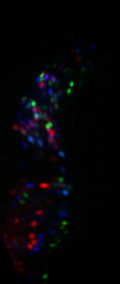

In [42]:

print(string(reg_timepts[dataset_immobilized_central])*"\n");
res = (0,0); ##params["mNeptune"]["registration_resolution_neuropal"]
print(joinpath(param_paths["mNeptune"]["path_dir_reg_neuropal"], "result.$(res[1]).R$(res[2]).nrrd")
    * "\n");
res = (0,0); ##params["OFP"]["registration_resolution_neuropal"]
print(joinpath(param_paths["OFP"]["path_dir_reg_neuropal"], "result.$(res[1]).R$(res[2]).nrrd")
    * "\n");
print(joinpath(param_paths["OFP"]["path_nrrd_avg_ch1toch2_reg"], "result.nrrd")
    * "\n");
print(joinpath(param_paths["BFP"]["path_nrrd_avg_ch1toch2_reg"], "result.nrrd")
    * "\n");
print(joinpath(param_paths["all_red"]["path_nrrd_avg"][2])
    * "\n");



res = (0,0); ##params["mNeptune"]["registration_resolution_neuropal"]
    mNeptune = read_img(NRRD(joinpath(param_paths["mNeptune"]["path_dir_reg_neuropal"], "result.$(res[1]).R$(res[2]).nrrd")))
    #res = params["mNeptune_gcamp"]["registration_resolution_neuropal"]
    #mNeptune_gcamp = read_img(NRRD(joinpath(param_paths["mNeptune_gcamp"]["path_dir_reg_neuropal"], "result.$(res[1]).R$(res[2]).nrrd")))
res = (0,0); ##params["OFP"]["registration_resolution_neuropal"]
    OFP = read_img(NRRD(joinpath(param_paths["OFP"]["path_dir_reg_neuropal"], "result.$(res[1]).R$(res[2]).nrrd")))
    OFP_GCaMP = read_img(NRRD(joinpath(param_paths["OFP"]["path_nrrd_avg_ch1toch2_reg"], "result.nrrd")))
    BFP = read_img(NRRD(joinpath(param_paths["BFP"]["path_nrrd_avg_ch1toch2_reg"], "result.nrrd")))
    all_red = read_img(NRRD(joinpath(param_paths["all_red"]["path_nrrd_avg"][2])))





    BFP = read_img(NRRD(param_paths[dataset_central]["path_bfp_img"])); # BFP, (spacing_lat, spacing_lat, spacing_axi))
    OFP = read_img(NRRD(param_paths[dataset_central]["path_ofp_img"])); # , OFP, (spacing_lat, spacing_lat, spacing_axi))
    OFP_GCaMP= read_img(NRRD(param_paths[dataset_central]["path_gcamp_img"])); #, OFP_GCaMP, (spacing_lat, spacing_lat, spacing_axi))
    all_red= read_img(NRRD(param_paths[dataset_central]["path_all_red_img"]));#, all_red, (spacing_lat, spacing_lat, spacing_axi))
    mNeptune= read_img(NRRD(param_paths[dataset_central]["path_mNeptune_img"]));#, mNeptune, (spacing_lat, spacing_lat, spacing_axi))
    img_roi=read_img(NRRD(param_paths[dataset_central]["path_neuron_img"])); #, img_roi, (spacing_lat, spacing_lat, spacing_axi))

println(string(size(all_red)))
RGB.( maxprj((BFP.-minimum(BFP)) ./ (maximum(BFP) - minimum(BFP)),dims=3),
    maxprj((mNeptune.-minimum(mNeptune)) ./ (maximum(mNeptune) - minimum(mNeptune)),dims=3),
    maxprj((OFP.-minimum(OFP)) ./ (maximum(OFP) - minimum(OFP)),dims=3),)


You can preview the dataset to view z-projected worm images here.

**IMPORTANT:** There is a known failure mode with the green laser on the confocal that affects channel 2 (red) fluorescence. This failure will cause the green laser to fail to distribute light uniformly over the entire recording, which will make your data unusable. You should carefully inspect the following images for artifacts which will manifest as vertical light and/or dark stripes. If such artifacts exist, your data will be unusable and you should not continue with processing.

In [ ]:
let
    dataset = "freely_moving"
    ch_view = 2 # 1 is blue or green, 2 is red
    figure(figsize=(10,10))
    dim = 1
    stack = nd2preview(param_paths[dataset]["path_nd2"], return_data=true, z_crop=params[dataset]["z_range"], ch=ch_view, n_z=params[dataset]["n_z"], dim=dim);
end

### Saving to NRRD

Expected runtime: 1 hour.

For more information, please refer to https://github.com/flavell-lab/ND2Process.jl

This section crops out piezo motion artifacts and saves each time point in the ND2 confocal recording as an NRRD file. If this section crashes, it may mean that you need to update the parameter `param["n_z"]`, or that your confocal recording terminated prematurely.

In [ ]:
for dataset in keys(datasets)
    param_path = param_paths[dataset]
    param = params[dataset]
    nd2_to_nrrd(param_path["path_nd2"], param_path["path_root_process"], param["spacing_lat"], param["spacing_axi"], true,
        x_crop=param["x_range"], y_crop=param["y_range"], z_crop=param["z_range"], θ=param["θ"], chs=param["list_ch"], n_z=param["n_z"],
        NRRD_dir_name=param_path["path_dir_nrrd"], MIP_dir_name=param_path["path_dir_MIP"])
end

You can view the raw data by uncommenting this code:

In [ ]:
let
    dataset = "freely_moving"
    t = 250
    ch = 2 # 1 is blue or green, 2 is red
    img = read_img(NRRD(joinpath(param_paths[dataset]["path_dir_nrrd"], param_paths[dataset]["get_basename"](t,ch)*".nrrd")));
    view_roi_3D(img, nothing, nothing, raw_contrast=2)
end

### Shear Correction

Expected runtime: 1 hour. GPU-accelerated.

The worm motion introduces shear into the frames, which needs to be corrected for subsequent steps of the pipeline to work well. Only the freely-moving dataset requires shear correction.

For more information, please see https://github.com/flavell-lab/FFTRegGPU.jl

In [ ]:
getpid()

In [ ]:
new_process = addprocs(1)[1]

In [ ]:
@everywhere workers() begin
    using ImageDataIO
end

In [ ]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere params=$params

In [ ]:
for dataset in datasets_freely_moving
    result = @spawnat new_process begin
        shear_params = Dict()
        shear_correction_nrrd!(param_paths[dataset], params[dataset], params[dataset]["ch_marker"], shear_params);
        shear_params
    end
    data_dicts[dataset]["shear_params"] = fetch(result)    
end

In [ ]:
rmprocs(new_process)

You can view the shear-corrected data by running this code. The shear-correction operates in the `z`-dimension, so it's recommended to set `axis` to 1 or 2 to be able to view the neurons in the `z`-axis.

In [ ]:
let
    t = 30
    ch = params["freely_moving"]["ch_activity"] #["ch_marker"]
    img1 = read_img(NRRD(joinpath(param_paths["freely_moving"]["path_dir_nrrd_shearcorrect"], param_paths["freely_moving"]["get_basename"](t,ch)*".nrrd")));
    ch = params["freely_moving"]["ch_marker"]
    img2 = read_img(NRRD(joinpath(param_paths["freely_moving"]["path_dir_nrrd_shearcorrect"], param_paths["freely_moving"]["get_basename"](t,ch)*".nrrd")));
    #view_roi_3D(img, nothing, nothing, raw_contrast=2, axis=3)
    Plots.plot(RGB.(maxprj(img2,dims=3)[:,:,1]/maximum(img2),maxprj(img1,dims=3)[:,:,1]/maximum(img1),0))
end

In [ ]:
log_prog("Shear Correction", param_paths["freely_moving"]["path_log_file"])

### Crop and rotate images

Expected runtime: 45 minutes. GPU-accelerated.

We next crop and rotate the images to avoid spending computation time dealing with empty pixels. Since we are dealing with freely moving animals, we cannot do this globally as allowed in `nd2_to_nrrd`, so we must instead do it on a frame-by-frame basis, modifying the cropping parameters each time to account for the worm's motion.

This code will usually give a warning about out-of-focus timepoints. If there are too many of them (eg: several hundred), your dataset likely had severe focus problems and it may give low quality data.

For more information, please refer to https://flavell-lab.github.io/SegmentationTools.jl/stable/crop

In [ ]:
new_process = addprocs(1)[1]

In [ ]:
@everywhere workers() begin
    using ImageDataIO
    using SegmentationTools
end

In [ ]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere params=$params

In [ ]:
for dataset = keys(datasets)
    result = @spawnat new_process begin
        dict_param_crop_rot = Dict()
        nrrd_key = (dataset in datasets_freely_moving) ? "path_dir_nrrd_shearcorrect" : "path_dir_nrrd"
        dict_error_crop_rot, focus_issues = crop_rotate_dset!(param_paths[dataset], params[dataset], params[dataset]["t_range"], [params[dataset]["ch_marker"]], dict_param_crop_rot, save_MIP=true, nrrd_dir_key=nrrd_key)
        
        dict_error_crop_rot, focus_issues, dict_param_crop_rot
    end
    error_dicts[dataset]["dict_error_crop_rot"], data_dicts[dataset]["focus_issues"], data_dicts[dataset]["dict_param_crop_rot"] = fetch(result)
end;

In [ ]:
rmprocs(new_process)

### Delete bad frames
Remove all time points where the worm was not visible or otherwise unusable. (Do not delete out of focus frames.)

In [ ]:
for dataset = keys(datasets)
    param = params[dataset]
    param["t_range"] = [t for t in param["t_range"] if !(t in keys(error_dicts[dataset]["dict_error_crop_rot"])) || error_dicts[dataset]["dict_error_crop_rot"][t] == ErrorException("Worm out of focus")]
    data_dicts[dataset]["t_range"] = param["t_range"]
    JLD2.@save(param_paths[dataset]["path_param"], param)
end

In [ ]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

### Total-Variation Noise Filtering

Expected runtime: 10 minutes. GPU-accelerated.

This script filters the cropped data in the marker (red) channel to denoise it and make it easier for the registration to converge. The channel alignment registration does not use filtered data.

For more information, please refer to https://github.com/flavell-lab/GPUFilter.jl

In [ ]:
new_process = addprocs(1)[1]

In [ ]:
@everywhere workers() begin
    using ImageDataIO
end

In [ ]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere params=$params

In [ ]:
for dataset = keys(datasets)
    result = @spawnat new_process begin
        filter_nrrd_gpu(param_paths[dataset], param_paths[dataset]["path_dir_nrrd_crop"], params[dataset]["t_range"], [params[dataset]["ch_marker"]], param_paths[dataset]["get_basename"])
    end
    fetch(result)
end

In [ ]:
rmprocs(new_process)

In [ ]:
log_prog("Cropping", param_paths["freely_moving"]["path_log_file"])

### Finding head location

Expected runtime: 20 minutes. GPU-accelerated.

The first step in determining which timepoints to register to each other is finding the location of the worm's head in the frames, and frames where the head cannot be found from the analysis. This is done with a custom-trained 2D UNet.

For more information, please refer to https://flavell-lab.github.io/SegmentationTools.jl/stable/find_head

In [ ]:
new_process = addprocs(1)[1]

In [ ]:
@everywhere workers() begin
    using ImageDataIO
    using NRRDIO
    using SegmentationTools
    using UNet2D
end

In [ ]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere params=$params

In [ ]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    error_dict = error_dicts[dataset]
    
    @eval @everywhere dict_param_crop_rot=$(data_dict["dict_param_crop_rot"])

    result = @spawnat new_process begin
        param_path = param_paths[dataset]
        param = params[dataset]
    
        nrrd_dir = (dataset in datasets_freely_moving) ? "path_dir_nrrd_shearcorrect" : "path_dir_nrrd"
        img_size = size(read_img(NRRD(joinpath(param_path[nrrd_dir], param_path["get_basename"](1,2)*".nrrd"))))
        model = create_model(1,1,8,param_path["path_head_unet_model"]);
        head_pos, head_errs = find_head_unet(param_path, param, dict_param_crop_rot, model, img_size, nrrd_dir=nrrd_dir, use_cropnet=true);
        if !(dataset in datasets_freely_moving)
            head_pos_uncropped, head_errs_uncropped = find_head_unet(param_path, param, dict_param_crop_rot, model, img_size, nrrd_dir=nrrd_dir, crop=false, use_cropnet=true);
        else
            head_pos_uncropped = nothing
            head_errs_uncropped = nothing
        end
        head_pos, head_errs, head_pos_uncropped, head_errs_uncropped
    end
    data_dict["head_pos"], error_dict["head_errs"], data_dict["head_pos_uncropped"], error_dict["head_errs_uncropped"] = fetch(result)
end;

In [ ]:
for dataset = datasets_freely_moving
    @eval @everywhere dict_param_crop_rot=$(data_dicts[dataset]["dict_param_crop_rot"])
    @eval @everywhere head_pos=$(data_dicts[dataset]["head_pos"])
    result = @spawnat new_process begin
        param_path = param_paths[dataset]
        param = deepcopy(params[dataset])
        param["t_range"] = [t for t in keys(dict_param_crop_rot) if "crop" in keys(dict_param_crop_rot[t]) && !(t in keys(head_pos))]
        nrrd_dir = "path_dir_nrrd"
        img_size = size(read_img(NRRD(joinpath(param_path[nrrd_dir], param_path["get_basename"](1,2)*".nrrd"))))
        model = create_model(1,1,8,param_path["path_head_unet_model"]);
        head_pos_new, head_errs_retry = find_head_unet(param_path, param, dict_param_crop_rot, model, img_size, nrrd_dir=nrrd_dir, use_cropnet=true);
        for t in keys(head_pos_new)
            head_pos[t] = head_pos_new[t]
        end
        head_pos, head_errs_retry
    end
    data_dicts[dataset]["head_pos"], error_dicts[dataset]["head_errs_retry"] = fetch(result)
end

In [ ]:
rmprocs(new_process)

This line of code tells you the fraction of times that the head-detection UNet was successful at determining the worm's head location. If this number is below 90%, it usually means that your dataset is very low quality. If you made a new strain and are consistently getting a value below 90%, you may need to retrain the 2D UNet on that strain. Additionally, you may want to use ImageClick to manually label head positions for this dataset.

In [ ]:
length(data_dicts["freely_moving"]["head_pos"]) / params["freely_moving"]["max_t"]

### Manually adjusting head position

This line of code lets you manually examine the head UNet output at individual timepoints in individual datasets. If you need to manually fix errors, you can comment out line 15 (`hp = data_dicts[dataset]["head_pos"][t]`) and uncomment line 16 (`hp = [x,y]`), replacing `x` and `y` with your manual estimates of the head position.

In [ ]:
let
    dataset = "freely_moving"#"all_red"
    t = 391#reg_timepts[dataset] # you may want to set this to reg_timepts[dataset] for immobilized datasets
    if !(t in keys(data_dicts[dataset]["head_pos"]))
        println(error_dicts[dataset]["head_errs_retry"][t])
    else
        println("Time point displayed: $t")
        contrast = 1
        
        path_nrrd = joinpath(param_paths[dataset]["path_dir_nrrd_crop"], param_paths[dataset]["get_basename"](t,2) * ".nrrd")
        img = maxprj(read_img(NRRD(path_nrrd)), dims=3)#[1:322,1:210]
        
        img_max = percentile(reshape(img, (prod(size(img)),)), 100-contrast)
        img_min = percentile(reshape(img, (prod(size(img)),)), contrast)
        
        img_hp = zeros(size(img))
        println("Image size: $(size(img))")
        hp = data_dicts[dataset]["head_pos"][t]
#         hp = [x,y]
        println("Detected head position: $(hp)")
        img_hp[hp[1]-5:hp[1]+5,
                hp[2]-5:hp[2]+5] .= 1
        
        RGB.(max.(0,min.(1,(img .- img_min) ./ (img_max - img_min))), img_hp, 0)
    end
end

If you need to manually adjust any incorrect or missing head positions, you can do so here by uncommenting this code and replacing `dataset`, `t`, `x`, and `y` with the appropriate values:

In [ ]:
# data_dicts[dataset]["head_pos"][t] = [x,y]

### Saving head position

In [ ]:
for dataset = datasets_freely_moving
    param = params[dataset]
    param["t_range"] = [t for t in param["t_range"] if (t in keys(data_dicts[dataset]["head_pos"]))]
    data_dicts[dataset]["t_range"] = param["t_range"]
    JLD2.@save(param_paths[dataset]["path_param"], param)
end

The following code will display a warning message if the head detector failed on any timepoints in any datasets that are being registered back to the freely-moving dataset. If this happens, it is recommended to run the code in "Manually adjusting head position" for `reg_timepts[dataset]"` and ensure that the value is correct, or modify it if it is not.

In [ ]:
for dataset = keys(datasets)
    f = open(param_paths[dataset]["path_head_pos"],"w")
    for t in params[dataset]["t_range"]
        if !(t in keys(data_dicts[dataset]["head_pos"]))
            if dataset in datasets_register
                @warn("$(dataset) timepoint $(t) head location not found.")
            end
            continue
        end
        hp = data_dicts[dataset]["head_pos"][t]
        write(f, "$(t)    $(hp[1]) $(hp[2])\n")
    end
    close(f)
end;

In [ ]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

In [ ]:
log_prog("Head Location", param_paths["freely_moving"]["path_log_file"])

# Registration

### Registration Graph

Expected runtime: 5 minutes.

This script determines which frames are similar to each other and generates a list of pairs of time points to register to each other. For more information, see https://flavell-lab.github.io/WormFeatureDetector.jl, https://github.com/flavell-lab/WormCurveFinder.jl, and https://flavell-lab.github.io/RegistrationGraph.jl.

Extremely rarely, the head detector will produce a head position even when the worm is not in the field of view (typically, due to a tracking glitch). If this happens, the following code blocks may crash, and any subsequent registration code will fail. If this happens, the solution is to find which timepoints in `param["t_range"]` are causing the crash and remove them. Typically the easiest way to do this is to look at either `data_dict["curves"]` or `data_dicts["$(dataset)_to_central"]["curves"]` and finding when the last successful timepoint was. If necessary, you can also binary search over the full set of timepoints until the problematic ones are identified.

Define registration graph for immobilized datasets:

In [ ]:
for dataset = keys(datasets)
    data_dicts[dataset]["registration_problems"] = []
    if dataset in datasets_freely_moving
        continue
    end
    for t=1:params[dataset]["max_t"]
        if t!=params[dataset]["reg_timept"]
            push!(data_dicts[dataset]["registration_problems"], (t,params[dataset]["reg_timept"]))
        end
    end
end

Define registration graph for immobilized to freely-moving registration:

In [ ]:
for dataset in datasets_register
    data_dicts["$(dataset)_to_central"] = Dict()
    data_dicts["$(dataset)_to_central"]["max_t"] = params["freely_moving"]["max_t"]+params[dataset]["max_t"]
    data_dicts["$(dataset)_to_central"]["curves"] = Vector{Tuple{Vector{Float64}, Vector{Float64}}}(undef, data_dicts["$(dataset)_to_central"]["max_t"])
    heur! = (t1, t2) -> elastix_difficulty_wormcurve!(data_dicts["$(dataset)_to_central"]["curves"], params["freely_moving"], param_paths["freely_moving"], param_paths[dataset], t1, t2, params["freely_moving"]["ch_marker"], save_curve_fig=false, max_fixed_t=params["freely_moving"]["max_t"]);
    data_dicts["$(dataset)_to_central"]["t_range"] = collect(deepcopy(params["freely_moving"]["t_range"]))
    append!(data_dicts["$(dataset)_to_central"]["t_range"], params[dataset]["t_range"].+params["freely_moving"]["max_t"])
    data_dicts["$(dataset)_to_central"]["elastix_difficulty"] = generate_elastix_difficulty(param_paths["freely_moving"]["path_elastix_difficulty_$(dataset)"], data_dicts["$(dataset)_to_central"]["t_range"], heur!);
end

In [ ]:
for dataset in datasets_register
    if dataset in datasets_freely_moving
        error("Registering freely-moving datasets together not yet supported in this version of ANTSUN. Please see old ANTSUN_merge.ipynb script.")
    else
        data_dicts["$(dataset)_to_central"]["registration_problems"] = []
        best_timepts = sort(1:length(params[dataset_central]["t_range"]), by=i->data_dicts["$(dataset)_to_central"]["elastix_difficulty"][1:end-length(params[dataset]["t_range"]), length(params[dataset_central]["t_range"])+params[dataset]["reg_timept"]][i])
        for i=1:n_timepts_merge[dataset]
            push!(data_dicts["$(dataset)_to_central"]["registration_problems"], (params[dataset]["reg_timept"], params[dataset_central]["t_range"][best_timepts[i]]))
        end
    end
end

Define registration graph for freely-moving dataset:

In [ ]:
for dataset in datasets_freely_moving
    data_dict = data_dicts[dataset]
    param = params[dataset]
    param_path = param_paths[dataset]
    data_dict["curves"] = Vector{Tuple{Vector{Float64}, Vector{Float64}}}(undef, param["max_t"])
    heur! = (t1, t2) -> elastix_difficulty_wormcurve!(data_dict["curves"], param, param_path, param_path, t1, t2, param["ch_marker"], save_curve_fig=true);
    data_dict["elastix_difficulty"] = fill(Inf, (param["max_t"], param["max_t"]))
    data_dict["elastix_difficulty"][param["t_range"], param["t_range"]] .= generate_elastix_difficulty(param_path["path_elastix_difficulty"], param["t_range"], heur!);
end;

If the following code displays any `Disconnected graph` warnings, they are usually safe to ignore if they are due to `Disconnected for merge`, but if you see any output of the form `Disconnected for i=`, that represents a serious problem and may require manually adjusting the registration graph to ensure it is connected. It is very likely that you will get such a message if you try running `ANTSUN` on fully-immobilized animals; in this case it is recommended to bypass the registration graph computation entirely and manually specify the graph.

In [ ]:
## THIS CODE WON'T WORK WITH >2 MERGES

for dataset in datasets_freely_moving
    param = params[dataset]
    param_path = param_paths[dataset]
    data_dict = data_dicts[dataset]
    error_dict = error_dicts[dataset]
    for i=1:(param["max_graph_num"] < param["max_t"] ? 2 : 1)
        path_diff_i = replace(param_path["path_elastix_difficulty"], ".txt"=>"_$(i).txt")
        if i == 1
            t_inc = [t for t in param["t_range"] if t <= param["max_graph_num"]]
        else
            t_inc = [t for t in param["t_range"] if t > param["max_graph_num"]]
        end

        open(path_diff_i, "w") do f
            write(f, string(t_inc)*"\n")
            write(f, replace(string(data_dict["elastix_difficulty"][t_inc, t_inc]), ";"=>"\n"))
        end

        graph = load_graph(path_diff_i, func=identity);
        subgraph, unconnected = make_voting_subgraph(graph, param["degree"])
        
        if length(unconnected) > 0
            @warn("Disconnected for i=$i: $unconnected")
        end
        output_graph(subgraph, replace(param_path["path_reg_prob"], ".txt"=>"_$(i).txt"))

        if i > 1
            path_diff_merge = replace(param_path["path_elastix_difficulty"], ".txt"=>"_merge$(i).txt")
            open(path_diff_merge, "w") do f
                t_merge = param["t_range"]
                write(f, string(t_merge)*"\n")

                diff_merge = deepcopy(data_dict["elastix_difficulty"])
                diff_merge[t_inc, t_inc] .= Inf

                t_inc_1 = [t for t in param["t_range"] if t <= param["max_graph_num"]]
                diff_merge[t_inc_1, t_inc_1] .= Inf

                write(f, replace(string(diff_merge[t_merge, t_merge]), ";"=>"\n"))
            end
            graph = load_graph(path_diff_merge, func=identity);
            subgraph, unconnected = make_voting_subgraph(graph, param["degree_dataset"])
            if length(unconnected) > 0
                println("Disconnected for merge: $unconnected. This should be OK to ignore.")
            end
            output_graph(subgraph, replace(param_path["path_reg_prob"], ".txt"=>"_merge$(i).txt"))
        end
    end
    # loads registration problems you previously computed from the graph
    if param["max_graph_num"] < param["max_t"]
        data_dict["registration_problems"] = load_registration_problems([replace(param_path["path_reg_prob"], ".txt"=>"_1.txt"), replace(param_path["path_reg_prob"], ".txt"=>"_2.txt"), replace(param_path["path_reg_prob"], ".txt"=>"_merge2.txt")]);
    else
        data_dict["registration_problems"] = load_registration_problems([replace(param_path["path_reg_prob"], ".txt"=>"_1.txt")]);
    end;
end

In [ ]:
for dataset = datasets_register
    open(param_paths[dataset_central]["path_reg_prob_$dataset"], "w") do f
        for problem in data_dicts["$(dataset)_to_central"]["registration_problems"]
            write(f, "$(problem[1]) $(problem[2])\n")
        end
    end
end
for dataset = keys(datasets)
    open(param_paths[dataset]["path_reg_prob"], "w") do f
        for problem in data_dicts[dataset]["registration_problems"]
            write(f, "$(problem[1]) $(problem[2])\n")
        end
    end
end

In [ ]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

for dataset = datasets_register
    data_dict = data_dicts["$(dataset)_to_central"]
    JLD2.@save(joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2"), data_dict)
end

In [ ]:
GC.gc()

In [ ]:
log_prog("Registration Graph", param_paths["freely_moving"]["path_log_file"])

In [ ]:
### I manually loaded in the registration problems from sreeparna's original data_dict
### load original data_dicts
orig_data_dicts = Dict()

for dataset in keys(datasets)
    if dataset in datasets_freely_moving
        # path_root_process = path_root_process_freelymoving
        path_root_process = "/data1/shared/panneuralGFP/data_processed/2024-07-17-01_output"
    else
        path_root_process = joinpath("/data1/shared/panneuralGFP/data_processed/2024-07-17-01_output/neuropal", datasets[dataset])
    end
    
    path_ = joinpath(path_root_process, "orig_data_dict.jld2")
    if isfile(path_)
        f = JLD2.jldopen(path_)
        orig_data_dicts[dataset] = f["data_dict"]
        close(f)
    else
        orig_data_dicts[dataset] = Dict()
    end           
end

for dataset in datasets_register
    path_root_process = "/data1/shared/panneuralGFP/data_processed/2024-07-17-01_output"
    path_ = joinpath(path_root_process, "orig_$(dataset)_registered_data_dict.jld2")
    if isfile(path_)
        f = JLD2.jldopen(path_)
        orig_data_dicts["$(dataset)_to_central"] = f["data_dict"]
        close(f)
    else
        orig_data_dicts["$(dataset)_to_central"] = Dict()
    end
end

In [ ]:
# use old registration problems from sreeparna
for dataset in keys(datasets)
    data_dicts[dataset]["registration_problems"] = copy(orig_data_dicts[dataset]["registration_problems"])
end

for dataset in datasets_register
    data_dicts["$(dataset)_to_central"]["registration_problems"] = copy(orig_data_dicts[dataset]["registration_problems"])
end

In [ ]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

for dataset = datasets_register
    data_dict = data_dicts["$(dataset)_to_central"]
    JLD2.@save(joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2"), data_dict)
end

In [ ]:
data_dicts[dataset_central]["registration_problems"]

## Registration on the OpenMind cluster

After the registration problems have been determined, the data can be uploaded to OpenMind. This code generates a number of registration scripts to run all of the immobilized to freely-moving, intra-dataset immobilized, and camera alignment registration problems using `elastix`, and then executes them all with `sbatch`. If you encounter errors here, it is likely that you have misconfigured something related to interfacing with OpenMind, either in a parameter setting in this notebook or on your computer (eg: `ssh` keys).

### Immobilized and camera alignment registration

Expected runtime: 1-8 hours.

#### Set up all intra-filter immobilized registrations in the red channel

In [ ]:
# syncs data to server and generates sbatch files for elastix
for dataset = keys(datasets)
    if dataset in datasets_freely_moving
        continue
    else
        @time write_sbatch_graph(data_dicts[dataset]["registration_problems"], param_paths[dataset], param_paths[dataset], params[dataset],
            nrrd_dir_key="path_dir_nrrd", nrrd_om_dir_key="path_om_nrrd")
    end
end

#### Set up camera alignment registration

In [ ]:
@time write_sbatch_graph([(x,x) for x in params[dataset_central]["t_range"]], param_paths[dataset_central], 
    param_paths[dataset_central], params[dataset_central], moving_channel_key="ch_activity",
    reg_dir_key="path_dir_reg_activity_marker", reg_om_dir_key="path_om_reg_activity_marker",
    nrrd_dir_key="path_dir_nrrd", nrrd_om_dir_key="path_om_nrrd",
    path_head_rotate_key="path_head_rotate_activity_marker", parameter_files_key="parameter_files_activity_marker",
    job_name_key="job_name_activity_marker", cmd_dir_key="path_dir_cmd_am", cmd_om_key="path_om_cmd_am", clear_cmd_dir=true);


#### Set up intra-filter immobilized registrations in the green channel

In [ ]:
for dataset = keys(datasets)
    if dataset in datasets_freely_moving
        continue
    end
    @time write_sbatch_graph(data_dicts[dataset]["registration_problems"], param_paths[dataset], param_paths[dataset], params[dataset],
        moving_channel_key="ch_activity", fixed_channel_key="ch_activity", reg_dir_key="path_dir_reg_activity",
        reg_om_dir_key="path_om_reg_activity", job_name_key="job_name_activity", cmd_dir_key="path_dir_cmd_activity", 
        cmd_om_key="path_om_cmd_activity", clear_cmd_dir=false, nrrd_dir_key="path_dir_nrrd", nrrd_om_dir_key="path_om_nrrd")
end


In [ ]:
paths_cmd = []
for dataset in keys(datasets)
    if !(dataset == dataset_central)
        push!(paths_cmd, param_paths[dataset]["path_om_cmd_array"])
    end
end

The following lines of code submit the jobs for running on OpenMind. Note that if the code is stalling for a long time without running, you may have a file that got stuck in your `lock` directory (this most commonly happens if a copy of `ANTSUN` fails to communicate with OpenMind to query whether its jobs are completed). Make sure that there is no other copy of `ANTSUN` that is currently running jobs on OpenMind, and then clear your `lock` directory to get the code to run.

In [ ]:
@time run_elastix_openmind(param_paths[dataset_central], params[dataset_central], extra_cmd_paths=paths_cmd)

In [ ]:
log_prog("OM Registration (jobs submitted)", param_paths["freely_moving"]["path_log_file"])

# Freely-moving registration

Expected runtime: 8 hours.

### Euler registration

Next, the images need to be transformed via rigid-body registration to initialize them for registration network processing.

Uses GPU. Expected runtime: 6 hours.

In [ ]:
#let
fixed_image_path=nothing
moving_image_path=nothing
    for dataset in datasets_freely_moving
        for moving in range(0,params[dataset]["max_t"])
            fixed_image_path = read_img(NRRD(param_paths[dataset_central]["path_all_red_img"]));
            moving_image_path = joinpath(param_paths[dataset]["path_dir_nrrd_filt_recropped"], param_paths[dataset]["get_basename"](moving,2)*".nrrd")
            #println( (fixed_image_path, moving_image_path)); rabbit
            # stack = nd2preview(moving_image_path, return_data=true, z_crop=params[dataset]["z_range"], ch=2, n_z=params[dataset]["n_z"], dim=dim);
            ### A = view_roi_3D(read_img(NRRD(moving_image_path)), nothing, nothing, raw_contrast=2)
        end
    end
view_roi_3D(read_img(NRRD(fixed_image_path))/255, read_img(NRRD(moving_image_path))/255, nothing, plot_size=(1200, 400), raw_contrast=3)

#end

In [ ]:
A=read_img(NRRD(fixed_image_path));
B=read_img(NRRD(moving_image_path));
(size(A), size(B))

In [67]:
new_process = addprocs(1)[1]

6

In [68]:
@everywhere workers() begin
    using ImageDataIO
    using PyCall
    using NRRDIO
    using Statistics
    using ImageRegistration
    using FlavellBase
    using ProgressMeter
    using MultivariateStats
end

      From worker 6:	┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
      From worker 6:	│ Please consider using an official build from https://julialang.org/downloads/.
      From worker 6:	└ @ CUDA ~/.julia/packages/CUDA/75aiI/src/initialization.jl:180
      From worker 6:	2025-01-17 16:02:32.586527: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
      From worker 6:	2025-01-17 16:02:32.586612: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
      From worker 6:	2025-01-17 16:02:32.587695: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [69]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere datasets=$datasets
@eval @everywhere params=$params
@eval @everywhere datasets_freely_moving=$datasets_freely_moving

In [70]:
#sleep(3600)

In [71]:
result = @spawnat new_process begin
    memory_dict = Dict()
    euler_parameters = Dict()
    #### Rabbit
    for dataset in datasets_freely_moving
        for moving in range(1,params[dataset]["max_t"])
            fixed_nrrd=NRRD(param_paths[dataset_central]["path_all_red_img"]);
            fixed_image = read_img(NRRD(param_paths[dataset_central]["path_all_red_img"]));   ### PRobably have to filter this...
            fixed=-1;
            moving_image_nrrd = NRRD(joinpath(param_paths[dataset]["path_dir_nrrd_filt_recropped"], param_paths[dataset]["get_basename"](moving,2)*".nrrd"))
            moving_image = read_img(moving_image_nrrd)
            temp=moving_image;
            moving_image=fixed_image;
            fixed_image=temp;
    
            euler_parameters[(moving, fixed)], euler_transformed_moving_image = euler_register!(param_paths[dataset], params[dataset], fixed_image, moving_image, memory_dict)
    
            save_dir = joinpath(param_paths[dataset]["path_dir_reg"], "$(moving)to$(fixed)")
            create_dir(save_dir)
            write_nrrd(joinpath(save_dir, "euler_transformed.nrrd"), Float32.(euler_transformed_moving_image), spacing(fixed_nrrd))
        end
    end
    euler_parameters
end

Future(6, 1, 59, ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (0, 0, 0)), nothing)

In [72]:
data_dicts[dataset_central]["euler_parameters"] = fetch(result);

In [73]:
rmprocs(new_process)

Task (done) @0x00007fcb7510b530

In [74]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    data_dict["t_range"] = params[dataset]["t_range"]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

for dataset = datasets_register
    data_dict = data_dicts["$(dataset)_to_central"]
    JLD2.@save(joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2"), data_dict)
end

In [75]:
log_prog("Euler Registration", param_paths["freely_moving"]["path_log_file"])

LoadError: UndefVarError: `log_prog` not defined

### Neural network registration with BrainAlignNet

The aligned images are next put into the registration network to compute DDFs for each registration problem.

Uses GPU. Expected runtime: 5 hours.

In [193]:
new_process = addprocs(1)[1]

15

In [194]:
@everywhere workers() begin
    # ENV["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
    using ImageDataIO
    using PyCall
    using NRRDIO
    using Statistics
    using ImageRegistration
    using FlavellBase
    using ProgressMeter
    using MultivariateStats
    using HDF5
end

      From worker 15:	┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
      From worker 15:	│ Please consider using an official build from https://julialang.org/downloads/.
      From worker 15:	└ @ CUDA ~/.julia/packages/CUDA/75aiI/src/initialization.jl:180
      From worker 15:	2025-01-18 21:40:39.685873: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
      From worker 15:	2025-01-18 21:40:39.685955: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
      From worker 15:	2025-01-18 21:40:39.686969: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registe

In [195]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere datasets=$datasets
#@eval @everywhere registration_problems=$(Dict(dataset => data_dicts[dataset]["registration_problems"] for dataset in datasets_freely_moving))
@eval @everywhere params=$params
@eval @everywhere datasets_freely_moving=$datasets_freely_moving

In [ ]:
param_paths["freely_moving"]["path_dir_reg"]

In some cases, if the registration failed or you want to update to a newer version of the network, you may want to delete all of your old registrations. To do so, uncomment the following blocks of code:

In [ ]:
### see what's in the folder before proceeding
# for dataset in datasets_freely_moving
#     @showprogress for problem in data_dicts[dataset]["registration_problems"]
#         path_tfm_img = joinpath(param_paths[dataset]["path_dir_reg"], "$(problem[1])to$(problem[2])", "predicted_fixed_image.nrrd")
#         if isfile(path_tfm_img)
#             rm(path_tfm_img)
#         end
#         path_ddf = joinpath(param_paths[dataset]["path_dir_reg"], "$(problem[1])to$(problem[2])", "ddf.h5")
#         if isfile(path_ddf)
#             rm(path_ddf)
#         end
#     end
# end

In [ ]:
let
    A= [];
    push!(A, 1)
    print(string(A))
end

flipOverX (generic function with 1 method)

In [184]:
let
     #  predict = pyimport("deepreg.predict");
     # predict.unwrapped_predict 
end 


LoadError: LoadError: UndefVarError: `@help` not defined
in expression starting at In[184]:5

In [196]:
result = @spawnat new_process begin

function flipOverX(initialImg)
    A=zeros(size(initialImg));
    for thisInd in range(1,size(A)[1])
        A[thisInd,:,:]=initialImg[end-thisInd+1,:,:];
    end
    return A;
end
    
    predict = pyimport("deepreg.predict")
    overwrite_existing = true # set this to `true` to overwrite existing registrations; otherwise the code will skip over them and focus on incomplete registrations
    model = nothing
    nrrd_spacing = nothing
    for dataset in datasets_freely_moving
        batch_size = params[dataset]["deepreg_batch_size"]
        for i in 1:batch_size:params[dataset]["max_t"]
            batch = range(i,min(i+batch_size-1, params[dataset]["max_t"]))
            fixed_images = zeros((batch_size, params[dataset]["crop_size"]...))
            moving_images = zeros((batch_size, params[dataset]["crop_size"]...))


            #=
                        fixed_nrrd=NRRD(param_paths[dataset_central]["path_all_red_img"]);
            fixed_image = read_img(NRRD(param_paths[dataset_central]["path_all_red_img"]));   ### PRobably have to filter this...
            fixed=-1;
            moving_image_nrrd = NRRD(joinpath(param_paths[dataset]["path_dir_nrrd_filt_recropped"], param_paths[dataset]["get_basename"](moving,2)*".nrrd"))
            moving_image = read_img(moving_image_nrrd)
            temp=moving_image;
            moving_image=fixed_image;
            fixed_image=temp;
    =#

      #      function flip
            
            
            for j in 1:length(batch)
                fixed,moving = (-1, batch[j]);
                fixed_nrrd = NRRD(joinpath(param_paths[dataset]["path_dir_nrrd_filt_recropped"], param_paths[dataset]["get_basename"](moving,2)*".nrrd"));
                if isnothing(nrrd_spacing)
                    nrrd_spacing = spacing(fixed_nrrd)
                end
                fixed_images[j,:,:,:] .= read_img(fixed_nrrd)
                # moving_images[j,:,:,:] .= read_img(NRRD(param_paths[dataset_central]["path_all_red_img"])); 
                #read_img(NRRD(joinpath(param_paths[dataset]["path_dir_reg"], "$(moving)to$(fixed)", "euler_transformed.nrrd")))
                moving_images[j,:,:,:] .= read_img(NRRD(joinpath(param_paths[dataset]["path_dir_reg"], "$(moving)to$(fixed)", "euler_transformed.nrrd")))


                fixed_images[j,:,:,:] .= flipOverX(fixed_images[j,:,:,:])           
                moving_images[j,:,:,:] .= flipOverX(moving_images[j,:,:,:])           

            end
            
            ddf, pred_fixed_image, model = predict.unwrapped_predict(fixed_images, moving_images, "/dev/null", params[dataset]["deepreg_label_size"], params[dataset]["deepreg_label_size"], model, param_paths[dataset]["path_deepreg_weights"], param_paths[dataset]["path_deepreg_config"])
            for (j, k) in enumerate(batch)
                ddf_batch = ddf[j,:,:,:,:]
                predicted_fixed_image_batch = pred_fixed_image[j,:,:,:]
                
                save_dir_problem = joinpath(param_paths[dataset]["path_dir_reg"], "$(k)to-1")
            
                h5open(joinpath(save_dir_problem, "ddf_flippedOverX.h5"), "w") do file
                    write(file, "ddf", ddf_batch)
                end
            
                write_nrrd(joinpath(save_dir_problem, "predicted_fixed_image_flippedOverX.nrrd"), Float32.(predicted_fixed_image_batch), nrrd_spacing)
            end
        end
    end
    nothing
end

Future(15, 1, 198, ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (0, 0, 141733920768)), nothing)

      From worker 15:	2025-01-18 21:41:06 | WARNING  | Log directory /dev/null exists already.
      From worker 15:	2025-01-18 21:41:06 | WARNING  | Using customized configuration. The code might break if the config doesn't match the saved model.


In [197]:
fetch(result)

In [198]:
rmprocs(new_process)

      From worker 15:	Built inputs.
      From worker 15:	Built control points.
      From worker 15:	Concatenated images.
      From worker 15:	{'extract_levels': ListWrapper([0, 1, 2, 3]), 'name': 'local', 'num_channel_initial': 16}
      From worker 15:	Built backbone.
      From worker 15:	Built DDF.
      From worker 15:	Built warping.


Task (done) @0x00007fcde70304c0

Dict{Any, Any}("best_transformation_xy" => Float32[-0.15, -0.22, 3.2986722], "registered_image_xyz_gncc_xz" => 0.7079833745956421, "best_transformation_xz" => Float32[0.0, 0.05, 0.0], "registered_image_xyz_gncc_xy" => 0.6812616586685181, "registered_image_xyz_gncc_1" => 0.42682363892707037, "registered_image_xyz_gncc_0" => 0.04540932866310949)
(284, 120)
(284, 120)
(284, 120)


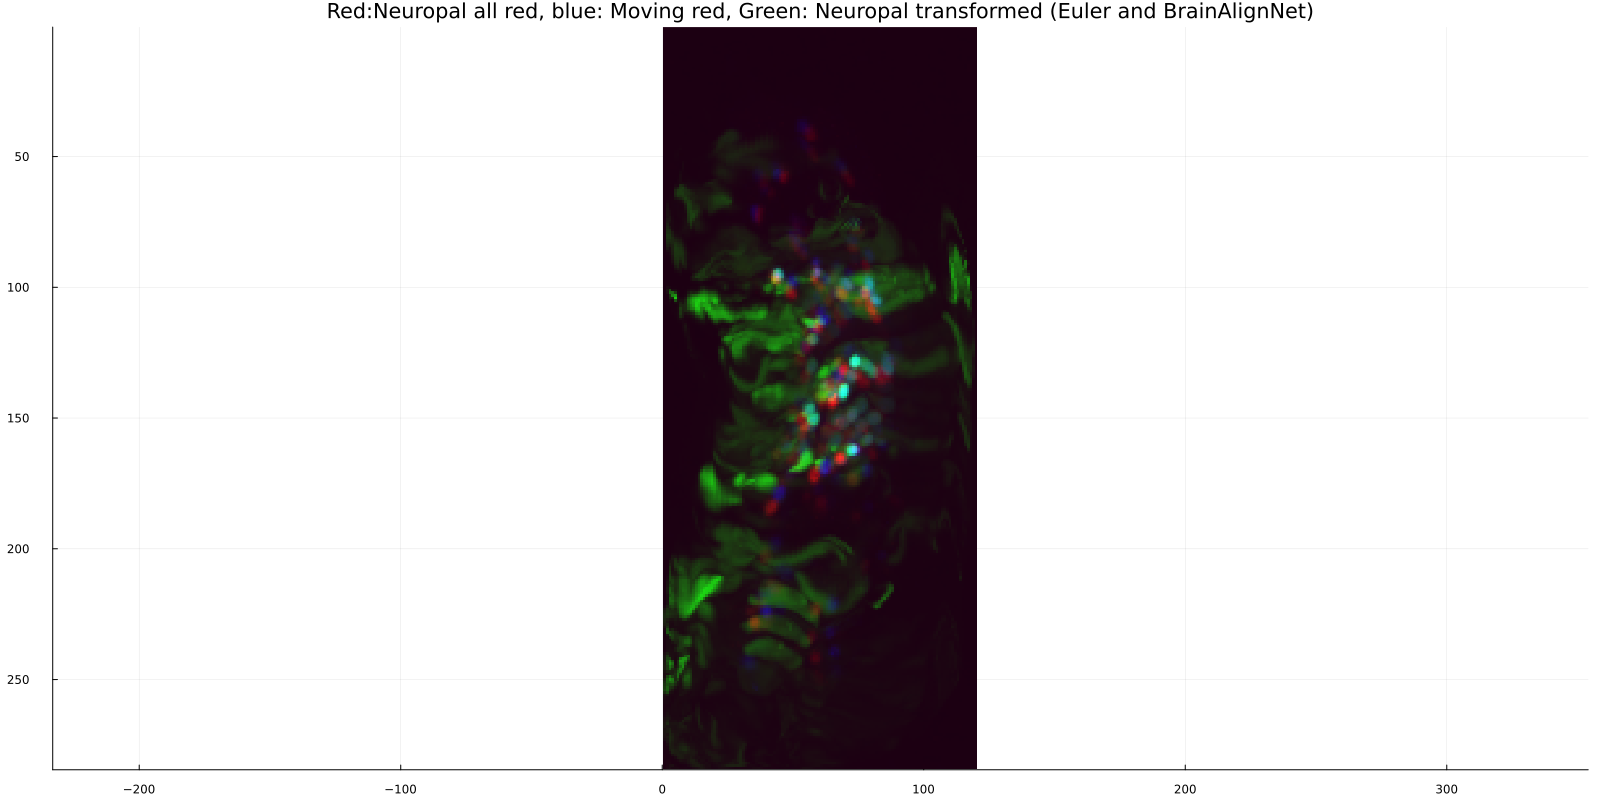

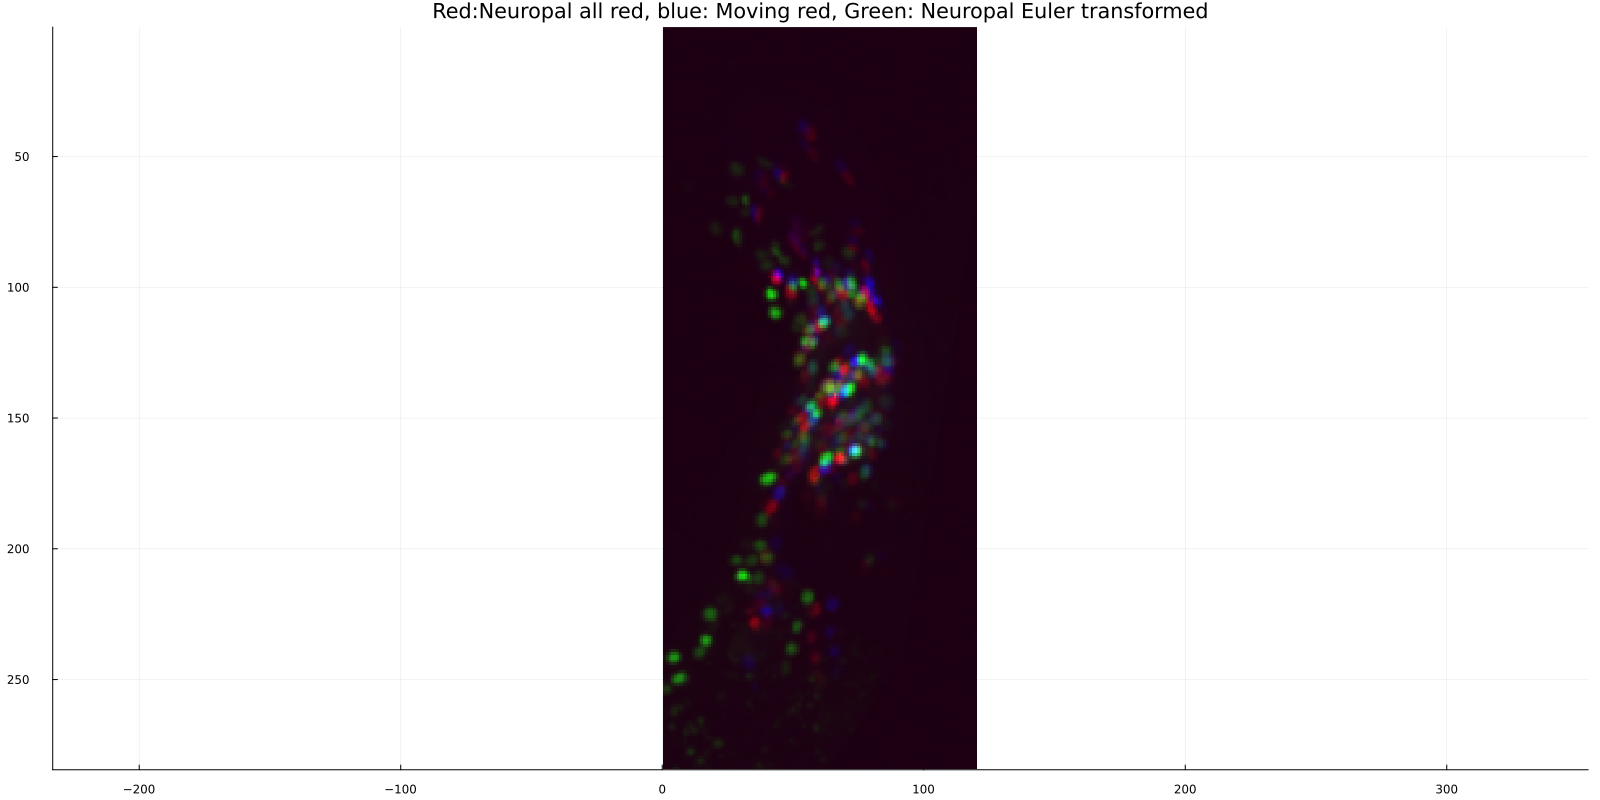

initialNeuropalRed : (284, 120)
fixed_nrrd : (284, 120)
transformedNeuropalRedImage : (284, 120)
eulerOnlyTransformedNeuropalRedImage : (284, 120)


In [203]:

function getNRRDImageAfterReadingAndCleanUp(thisPath)
    initialImg=read_img(NRRD(thisPath));

    A=zeros(size(initialImg));
    for thisInd in range(1,size(A)[1])
        A[thisInd,:,:]=initialImg[end-thisInd+1,:,:];
    end
    initialImg=A;
    initialImg=(initialImg.-minimum(initialImg))./(maximum(initialImg)-minimum(initialImg))
    finalImg = maxprj(initialImg,dims=3);
    return finalImg;
end



    k=1500;
    #=
    initialNeuropalRed_1=read_img(NRRD(param_paths[dataset_central]["path_all_red_img"]));
    initialNeuropalRed_1=(initialNeuropalRed_1.-minimum(initialNeuropalRed_1))./(maximum(initialNeuropalRed_1)-minimum(initialNeuropalRed_1))
    initialNeuropalRed = maxprj(initialNeuropalRed_1,dims=3); 
    =#
    initialNeuropalRed=getNRRDImageAfterReadingAndCleanUp(param_paths[dataset_central]["path_all_red_img"]);

    #=
# "euler_transformed.nrrd"))); #
    dataset=datasets_freely_moving[1]
    save_dir_problem = joinpath(param_paths[dataset]["path_dir_reg"], "$(k)to-1")
    transformedNeuropalRedImage_1=read_img(NRRD(joinpath(save_dir_problem, "predicted_fixed_image.nrrd")));   
    transformedNeuropalRedImage_1=(transformedNeuropalRedImage_1.-minimum(transformedNeuropalRedImage_1))./(maximum(transformedNeuropalRedImage_1)-minimum(transformedNeuropalRedImage_1))
    transformedNeuropalRedImage=maxprj(transformedNeuropalRedImage_1,dims=3)
    =#
    save_dir_problem = joinpath(param_paths[dataset]["path_dir_reg"], "$(k)to-1")
    transformedNeuropalRedImage=getNRRDImageAfterReadingAndCleanUp(joinpath(save_dir_problem, "predicted_fixed_image.nrrd"));



    println(string(data_dicts[dataset_central]["euler_parameters"][(k,-1)]))

    #=
    fixed_nrrd_1 = read_img(NRRD(joinpath(param_paths[dataset]["path_dir_nrrd_filt_recropped"], param_paths[dataset]["get_basename"](k,2)*".nrrd")));
    fixed_nrrd_1=(fixed_nrrd_1.-minimum(fixed_nrrd_1))./(maximum(fixed_nrrd_1)-minimum(fixed_nrrd_1))
    fixed_nrrd = maxprj(fixed_nrrd_1,dims=3);
    =#
    # _flippedOverX
    fixed_nrrd = getNRRDImageAfterReadingAndCleanUp(joinpath(param_paths[dataset]["path_dir_nrrd_filt_recropped"], param_paths[dataset]["get_basename"](k,2)*".nrrd"));
    initialNeuropalRed = getNRRDImageAfterReadingAndCleanUp(joinpath(param_paths[dataset]["path_dir_nrrd_filt_recropped"], param_paths[dataset]["get_basename"](k+1,2)*".nrrd"));

println(size(fixed_nrrd));
println(size(transformedNeuropalRedImage));
println(size(initialNeuropalRed));

display(Plots.plot(RGB.( initialNeuropalRed, transformedNeuropalRedImage , fixed_nrrd),size=(1600,800),
        title="Red:Neuropal all red, blue: Moving red, Green: Neuropal transformed (Euler and BrainAlignNet)"))

eulerOnlyTransformedNeuropalRedImage=getNRRDImageAfterReadingAndCleanUp(joinpath(save_dir_problem, "euler_transformed.nrrd"));

display(Plots.plot(RGB.( initialNeuropalRed, eulerOnlyTransformedNeuropalRedImage , fixed_nrrd),size=(1600,800),
        title="Red:Neuropal all red, blue: Moving red, Green: Neuropal Euler transformed"))



for thisSymb in [:initialNeuropalRed, :fixed_nrrd, :transformedNeuropalRedImage, :eulerOnlyTransformedNeuropalRedImage]
        println( string(thisSymb) *" : " * string(size(eval(thisSymb))));
end

In [ ]:
log_prog("NN Registration", param_paths["freely_moving"]["path_log_file"])

### Make HDF5 files from NRRD files

The U-Net requires data to be input in HDF5 format. Make sure to use the original NRRD files, **not** any noise-filtered version.

In [ ]:
for dataset in keys(datasets)
    make_unet_input_h5(param_paths[dataset], param_paths[dataset]["path_dir_nrrd_crop"], params[dataset]["t_range"], params[dataset]["ch_marker"], param_paths[dataset]["get_basename"])
end

### Run `pytorch-3dunet`

Expected runtime: 1 hour.

This command runs the 3D-UNet to segment neurons on the current dataset.

Note that this step can crash if you are out of GPU memory. If it does so, restart the kernel, rerun "Initialize data dictionaries", then rerun this step and all subsequent steps.

In [ ]:
for dataset in keys(datasets)
    param_path = param_paths[dataset]

    param_path["path_unet_pred"] = "/home/candy/src/pytorch-3dunet/pytorch3dunet/predict.py" # Path to the pytorch-3dunet installation on the local machine
    param_path["path_unet_param"] = "/store1/candy/prj_register/SegNet_upto43_ericHP/instance_segmentation_test.yaml" # Path to the UNet parameter file
    param_path["path_unet_py_env"] = "/home/candy/.julia/conda/3/x86_64/bin/activate" # Path to a script that should be run to configure environment variables for the pytorch-3dunet
    
    @time call_unet(param_paths[dataset], gpu=gpu_device)
end

The UNet segmentation used the GPU, so we can try to free GPU memory here, though note that the kernel will need to be restarted before all memory can be freed.

### Watershedding Concave Neurons

Expected runtime: 1 hour.

The U-Net often fails to completely instance segment neurons, which leaves oddly-shaped and concave neurons that need further segmentation. We use a customized watershed algorithm for this. There are a bunch of heuristic keyword parameters in `instance_segment_threshold` to play around with, if it doesn't work well initally.

In [ ]:
for dataset in keys(datasets)

    ### UNet
    params[dataset]["seg_threshold_unet"] = 0.55 # The UNet output confidence threshold for a pixel to be counted as a neuron.
    params[dataset]["seg_min_neuron_size"] = 6 # Neurons with fewer than this many voxels will be discarded.
    params[dataset]["seg_threshold_watershed"] = [0.6, 0.7, 0.8, 0.9, 0.95] #= The image is re-segmented at these thresholds,
        and checked for neurons that were split - these neurons will be segmented by watershed.=#
    params[dataset]["seg_watershed_min_neuron_sizes"] = [6, 5, 4, 4, 4] #= When the image is re-segmented, neurons smaller
        than the size for the corresponding threshold will be discarded.=#
    params[dataset]["instance_seg_num_batches"] = 5 # number of batches of data to run simultaneously
        # each batch = number of threads. Lower number = less memory used, but more chance of bad parity
    
    error_dicts[dataset]["seg_error"] = instance_segmentation_watershed(params[dataset], param_paths[dataset], param_paths[dataset]["path_dir_nrrd_crop"],
            params[dataset]["t_range"], param_paths[dataset]["get_basename"], save_centroid=true, save_signal=true, save_roi=true);
end

You can view the segmentation quality at a given time point by uncommenting this code:

In [ ]:
let
    t = 221 
    raw_contrast = 3
    param_path = param_paths[dataset_central]
    param = params[dataset_central]
    view_roi_3D(read_img(NRRD(joinpath(param_path["path_dir_nrrd_crop"], param_path["get_basename"](t, param["ch_marker"])*".nrrd"))), load_predictions(joinpath(param_path["path_dir_unet_data"], "$(t)_predictions.h5")), read_img(NRRD(joinpath(param_path["path_dir_roi_watershed"], "$(t).nrrd"))), plot_size=(1200, 400), raw_contrast=raw_contrast)
end

In [ ]:
log_prog("Instance Segmentation", param_paths["freely_moving"]["path_log_file"])

# Transform ROI images

Next, the ROIs need to be transformed through the network's DDFs to match neurons between time points.

Uses GPU. Expected runtime: 2 hours.

In [ ]:
### check if path_dir_roi_watershed and path_dir_roi_watershed_recropped are equal
param_paths[dataset_central]["path_dir_roi_watershed_recropped"] = param_paths[dataset_central]["path_dir_roi_watershed"]

In [ ]:
# @showprogress for t in params[dataset_central]["t_range"]
#     nrrd_roi = NRRD(joinpath(param_paths[dataset_central]["path_dir_roi_watershed"], "$(t).nrrd"))
#     roi_image = read_img(nrrd_roi)
#     cropped_roi_image = zeros(params[dataset_central]["crop_size"]...)
#     cropped_roi_image[data_dicts[dataset_central]["padded_slices"][t]...] = roi_image[data_dicts[dataset_central]["original_slices"][t]...]
#     write_nrrd(joinpath(param_paths[dataset_central]["path_dir_roi_watershed_recropped"], "$(t).nrrd"), floor.(UInt16, clamp.(cropped_roi_image, typemin(UInt16), typemax(UInt16))), spacing(nrrd_roi))
# end

In [ ]:
let
using PyCall
    euler_gpu = pyimport("euler_gpu")
    pytorch = pyimport("torch")

    # testImage1= pytorch.id(1,3,3)
    
    euler_gpu.transform_image

    A=pytorch.zeros(1,10,10,3);
    #py"for x in range(0,3):
    #A[0,0,0,0] =1;"
    
    for x in range(0,2)
        A[0,:,:,x] = pytorch.eye(10,10) * (x+1); 
    end
end

In [173]:
new_process = addprocs(1)[1]

13

In [174]:
@everywhere workers() begin
    using ImageDataIO
    using PyCall
    using NRRDIO
    using Statistics
    using ImageRegistration
    using FlavellBase
    using MultivariateStats
    using HDF5
end

      From worker 13:	┌ Warning: You are using a non-official build of Julia. This may cause issues with CUDA.jl.
      From worker 13:	│ Please consider using an official build from https://julialang.org/downloads/.
      From worker 13:	└ @ CUDA ~/.julia/packages/CUDA/75aiI/src/initialization.jl:180
      From worker 13:	2025-01-18 21:05:58.858366: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
      From worker 13:	2025-01-18 21:05:58.858444: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
      From worker 13:	2025-01-18 21:05:58.859446: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registe

In [175]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere datasets=$datasets
@eval @everywhere euler_parameters=$(Dict(dataset => data_dicts[dataset]["euler_parameters"] for dataset in datasets_freely_moving))
# @eval @everywhere original_slices=$(Dict(dataset => data_dicts[dataset]["original_slices"] for dataset in datasets_freely_moving))
# @eval @everywhere padded_slices=$(Dict(dataset => data_dicts[dataset]["padded_slices"] for dataset in datasets_freely_moving))
@eval @everywhere params=$params
@eval @everywhere datasets_freely_moving=$datasets_freely_moving

In [176]:
result = @spawnat new_process begin
    tf = pyimport("tensorflow")
    layer = pyimport("deepreg.model.layer")

    memory_dict = Dict()
    error_dicts = Dict()

    for dataset in datasets_freely_moving
        error_dicts[dataset] = Dict()
        for moving in 1:(params[dataset]["max_t"])
            problem=(moving,-1);
            # try
                                
                nrrd_roi = NRRD(joinpath(param_paths[dataset]["path_dir_roi_watershed"], "$(moving).nrrd"))
                # moving_roi_image = read_img(nrrd_roi)
                # cropped_moving_roi_image = zeros(params[dataset]["crop_size"]...)
                # cropped_moving_roi_image[padded_slices[dataset][moving]...] = moving_roi_image[original_slices[dataset][moving]...]
                cropped_moving_roi_image = read_img(nrrd_roi)
        
                euler_transformed_moving_roi_image = euler_transform_roi(cropped_moving_roi_image, euler_parameters[dataset][problem]["best_transformation_xy"], euler_parameters[dataset][problem]["best_transformation_xz"], memory_dict)
        
                ddf = nothing
        
                h5open(joinpath(param_paths[dataset]["path_dir_reg"], "$(problem[1])to$(problem[2])", "ddf.h5"), "r") do f
                    ddf = read(f["ddf"])
                end
        
                warping = layer.Warping(fixed_image_size=params[dataset]["crop_size"], batch_size=1, interpolation="nearest")
                euler_transformed_moving_roi_image_tf = tf.cast(tf.expand_dims(euler_transformed_moving_roi_image, axis=0), tf.float32)
# DBayani,m26htw23d11M1y2025
                # LOOKS LIKE DDF TAKES THE MOVING TO THE FIXED.
                ddf_transformed_roi_image = warping(inputs=[ddf, euler_transformed_moving_roi_image_tf]).numpy()[1,:,:,:]
        
                save_dir = joinpath(param_paths[dataset]["path_dir_transformed"], "$(moving)to$(fixed)")
                create_dir(save_dir)
        
                write_nrrd(joinpath(save_dir, "ROI_transformed_result.nrrd"), floor.(UInt16, clamp.(ddf_transformed_roi_image, typemin(UInt16), typemax(UInt16))), spacing(nrrd_roi))
            #catch e
            #    error_dicts[dataset][problem] = e
            #end
        end
    end
    error_dicts
end

Future(13, 1, 152, ReentrantLock(nothing, 0x00000000, 0x00, Base.GenericCondition{Base.Threads.SpinLock}(Base.IntrusiveLinkedList{Task}(nothing, nothing), Base.Threads.SpinLock(0)), (0, 0, 141733920768)), nothing)

In [177]:
fetch(result)

LoadError: On worker 13:
SystemError: opening file "/home/david/store1/david/data_pretrain_inferFluorescence_d16M1y2025/nueropalPerTimestep/data_processed/2024-07-17-01_output/img_roi_watershed/1.nrrd": No such file or directory
Stacktrace:
  [1] [0m[1m#systemerror#83[22m
[90m    @[39m [90m./[39m[90m[4merror.jl:176[24m[39m
  [2] [0m[1m#systemerror#82[22m
[90m    @[39m [90m./[39m[90m[4merror.jl:175[24m[39m[90m [inlined][39m
  [3] [0m[1msystemerror[22m
[90m    @[39m [90m./[39m[90m[4merror.jl:175[24m[39m[90m [inlined][39m
  [4] [0m[1m#open#705[22m
[90m    @[39m [90m./[39m[90m[4miostream.jl:293[24m[39m
  [5] [0m[1mopen[22m
[90m    @[39m [90m./[39m[90m[4miostream.jl:275[24m[39m[90m [inlined][39m
  [6] [0m[1m#open#707[22m
[90m    @[39m [90m./[39m[90m[4miostream.jl:356[24m[39m
  [7] [0m[1mopen[22m
[90m    @[39m [90m./[39m[90m[4miostream.jl:355[24m[39m
  [8] [0m[1m#open#409[22m
[90m    @[39m [90m./[39m[9

In [ ]:
for dataset in datasets_freely_moving
    error_dicts[dataset]["roi_warp_errors"] = result[dataset]
end

In [172]:
for dataset in datasets_freely_moving
    print(string(result["freely_moving"])[:300])
end

r

In [166]:
rmprocs(new_process)

Task (done) @0x00007fcb715fd5f0

In [168]:
error_dicts[dataset_central]["roi_warp_errors"]

LoadError: KeyError: key "roi_warp_errors" not found

In [ ]:
for dataset in datasets_freely_moving
    data_dicts[dataset]["roi_centroids_recropped"] = Dict()
    @showprogress for t in params[dataset]["t_range"]
        img_roi_watershed = read_img(NRRD(joinpath(param_paths[dataset]["path_dir_roi_watershed_recropped"], "$(t).nrrd")))
        data_dicts[dataset]["roi_centroids_recropped"][t] = get_centroids_preservenum(img_roi_watershed)
    end

    data_dicts[dataset]["roi_centroids_transformed"] = Dict()
    @showprogress for problem in data_dicts[dataset]["registration_problems"]
        img_roi_watershed = read_img(NRRD(joinpath(param_paths[dataset]["path_dir_transformed"], "$(problem[1])to$(problem[2])", "result.nrrd")))
        data_dicts[dataset]["roi_centroids_transformed"][problem] = get_centroids_preservenum(img_roi_watershed)
    end
    
    data_dicts[dataset]["roi_displacement"] = Dict()
    @showprogress for problem in data_dicts[dataset]["registration_problems"]
        moving, fixed = problem
        data_dicts[dataset]["roi_displacement"][problem] = Dict()
        ddf = Dict()
        h5open(joinpath(param_paths[dataset]["path_dir_reg"], "$(moving)to$(fixed)", "ddf.h5"), "r") do f
            ddf["ddf"] = read(f["ddf"])
        end
        ddf = ddf["ddf"]
        fixed_roi = read_img(NRRD(joinpath(param_paths[dataset]["path_dir_roi_watershed_recropped"], "$(fixed).nrrd")))
        dist_dict = Dict()
        for i in 1:size(data_dicts[dataset]["roi_centroids_recropped"][problem[2]],1)
            x, y, z = Int.(round.(data_dicts[dataset]["roi_centroids_recropped"][problem[2]][i,:]))
            if x > 0
                dist_dict[i] = [norm(ddf[x,y,z,:])]  # Is this backwards?....
            end
        end
        for roi_val in keys(dist_dict)
            data_dicts[dataset]["roi_displacement"][problem][roi_val] = mean(dist_dict[roi_val])
        end
    end
    data_dicts[dataset]["centroid_dist_dict"] = compute_centroid_dist_dict(data_dicts[dataset]["roi_centroids_recropped"], data_dicts[dataset]["roi_centroids_transformed"], max_dist=params[dataset]["max_centroid_dist"])
end

In [ ]:
new_process = addprocs(1)[1]

In [ ]:
@everywhere workers() begin
    using HDF5
    using PyCall
    using ImageDataIO
end

In [ ]:
@eval @everywhere param_paths=$param_paths
@eval @everywhere datasets=$datasets
@eval @everywhere registration_problems=$(Dict(dataset => data_dicts[dataset]["registration_problems"] for dataset in datasets_freely_moving))
@eval @everywhere params=$params
@eval @everywhere datasets_freely_moving=$datasets_freely_moving
@eval @everywhere dataset_central=$dataset_central

In [ ]:
for dataset in datasets_freely_moving

ddf_ = zeros(params[dataset]["crop_size"]..., 3)
file_path = joinpath(param_paths[dataset]["path_dir_reg"], "11to1430", "ddf.h5")
print(file_path * "\n");
    
h5open(file_path, "r") do file
    ddf_[:,:,:,:] .= file["ddf"][:,:,:,:]
    ddf_ = reshape(ddf_, (1, size(ddf_)...))
end

print(ddf_[1,100,100,32,:])
print(maximum( map(x->abs(x), ddf_[1,:,:,:,:]) )  )
np=pyimport("numpy")
np.save("/home/david/temp_ddf.npy", ddf_)
#py"print('hi')"
# deepreg_loss = pyimport("deepreuuuuuuuuuuug")
end

In [ ]:
result = @spawnat new_process begin
    reg_metric_dict = Dict()

    deepreg_loss = pyimport("deepreg.loss.deform")
    nonrigid_penalty = deepreg_loss.NonRigidPenalty(params[dataset_central]["crop_size"])

    for dataset in datasets_freely_moving
        reg_metric_dict[dataset] = Dict()
    
        for problem in registration_problems[dataset]
            ddf_ = zeros(params[dataset]["crop_size"]..., 3)
            file_path = joinpath(param_paths[dataset]["path_dir_reg"], "$(problem[1])to$(problem[2])", "ddf.h5")
        
            h5open(file_path, "r") do file
                ddf_[:,:,:,:] .= file["ddf"][:,:,:,:]
                ddf_ = reshape(ddf_, (1, size(ddf_)...))
            end
        
            if isnothing(ddf_)
                @warn "No DDF found for $(problem[1])to$(problem[2])"
                continue
            end
        
            reg_metric_dict[dataset][problem] = Dict()
            reg_metric_dict[dataset][problem]["nonrigid_penalty"] = nonrigid_penalty(ddf_).numpy()[1]
        end
    end
    reg_metric_dict
end

In [ ]:
fetch(result)

In [ ]:
for dataset in datasets_freely_moving
    data_dicts[dataset]["reg_metric_dict"] = result[dataset]
end

In [ ]:
rmprocs(new_process)

In [ ]:
for dataset = keys(datasets)
    data_dict = data_dicts[dataset]
    data_dict["t_range"] = params[dataset]["t_range"]
    JLD2.@save(param_paths[dataset]["path_data_dict"], data_dict)
end

for dataset = datasets_register
    data_dict = data_dicts["$(dataset)_to_central"]
    JLD2.@save(joinpath(param_paths[dataset_central]["path_root_process"], "$(dataset)_registered_data_dict.jld2"), data_dict)
end

In [ ]:
log_prog("Transform ROI Images", param_paths["freely_moving"]["path_log_file"])